# 4 · Règle de Bayes — solutions (notebook exécuté)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cemah2/workbookIA/blob/main/chapitres/ch04_bayes/05_solutions.ipynb)

Les réponses des exercices, exécutées. Les démarches détaillées (le *pourquoi*, les erreurs fréquentes, les variantes) sont dans `05_solutions.md`. Les cellules marquées `answer` enregistrent les réponses vérifiées par `wb.check` (`tools/build_answers.py`).

| Partie | ID | Titre | Type | ★ | ⏱️ |
|---|---|---|---|---|---|
| 0 | 4.1, 4.2, 4.4, 4.5, 4.6, 4.8 | vérifier tes exercices papier ✏️ | ✏️ | ★ à ★★ | |
| A | 4.12 | Combien de lancers pour démasquer la pièce truquée ? | 🔮 | ★ | 10 |
|  | 4.13 | L'estimation fréquentiste : la moyenne courante des faces | 🔬 | ★ | 15 |
|  | 4.14 | evidence et bayes_posterior | 🔨 | ★★ | 20 |
|  | 4.15 | Bayes chez les manchots : l'espèce sachant l'île | 📦 | ★★ | 20 |
| B | 4.16 | La boucle posterior-prior : update_discrete | 🔨 | ★★ | 30 |
|  | 4.17 | Reproduire les trente lancers de la figure 4.24 | 🎨 | ★★ | 25 |
|  | 4.18 | Le posterior qui s'évanouit : underflow | 🐛 | ★★ | 20 |
|  | 4.19 | La grille biais × proportion de faces | 🔬 | ★★ | 30 |
|  | 4.20 | Envoyer des sondes jusqu'à la décision | 🔬 | ★★ | 25 |
| C | 4.21 | Un prior trompeur centré sur 0,8 | 🔮 | ★★ | 20 |
|  | 4.22 | Le posterior continu : vérifier avec scipy.stats.beta | 📦 | ★★ | 20 |
|  | 4.23 | Refactoriser : du copier-coller à une fonction testée | 🛠️ | ★★ | 20 |
| D | 4.24 | coin_bias_posterior : 500 hypothèses en log-probabilités | 🔨 | ★★★ | 35 |
|  | 4.25 | Intervalle de crédibilité contre intervalle bootstrap | 🔨 | ★★★ | 35 |
|  | 4.26 | Le détective de pièces : vingt pièces, le moins de lancers possible | 🏆 | ★★★ | 60 |

In [1]:
# ⚙️ SETUP: run this cell first (on Colab or on your computer)
FAST_MODE = True  # True = quick version (CPU, a few minutes); False = full version
SEED = 42

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/cemah2/workbookIA.git"
DRIVE_DIR = Path("/content/drive/MyDrive/workbookIA")

try:
    import google.colab  # noqa: F401  (this module only exists on Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(DRIVE_DIR)])
    if not (DRIVE_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(DRIVE_DIR)], check=True)
    else:
        # Get the new chapters. Your own work only lives in mon_travail/, which Claude never
        # touches, so "rebase + autostash" keeps it safe (even with local commits).
        identity = subprocess.run(["git", "-C", str(DRIVE_DIR), "config", "user.email"],
                                  capture_output=True).returncode == 0
        who = [] if identity else ["-c", "user.name=Workbook", "-c", "user.email=workbook@localhost"]
        pull = subprocess.run(["git", *who, "-C", str(DRIVE_DIR), "pull", "--rebase", "--autostash"],
                              capture_output=True, text=True)
        if pull.returncode != 0:
            print("⚠️ git pull a échoué (voir 00_setup/COLAB.md, « Problèmes fréquents ») :\n" + pull.stderr)
    ROOT = DRIVE_DIR
else:
    ROOT = Path(os.environ.get("WB_ROOT", Path.cwd())).resolve()
    while not (ROOT / "src" / "wb").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    if not (ROOT / "src" / "wb").exists():
        raise FileNotFoundError("Dépôt introuvable : ouvre ce notebook depuis le dossier du workbook.")

os.environ["WB_ROOT"] = str(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import wb  # noqa: E402

cfg = wb.setup(seed=SEED, fast=FAST_MODE)
FAST_MODE = cfg.fast
mylearn = wb.load_mylearn("ref")  # reference implementation

🧪 Deep Learning Workbook : environnement
   Plateforme : Local (Linux x86_64, 2 CPU)
   Python 3.13.13 | numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | scikit-learn 1.6.1 | scipy 1.16.3 | torch 2.11.0+cpu | torchvision 0.26.0+cpu
   Device : cpu | Graine : 42 | FAST_MODE : True


## Objectifs et rappel express

- Calculer un posterior avec la règle de Bayes, pour deux puis pour plusieurs hypothèses.
- Mettre à jour une croyance observation après observation (la boucle posterior → prior), sans underflow.
- Relier la règle de Bayes à la precision d'un test et à la prévalence.
- Résumer un posterior par son MAP et un intervalle de crédibilité, et le comparer au bootstrap.

**Rappel express.** $P(H \mid O) = \frac{P(O \mid H)\,P(H)}{P(O)}$ avec $P(O) = \sum_i P(O \mid H_i)\,P(H_i)$ ; le posterior d'une observation est le prior de la suivante ; en log : $\log P(\theta \mid \text{données}) = \log P(\theta) + h\log\theta + t\log(1 - \theta) + \text{cste}$, puis on retranche le maximum avant l'exponentielle ; prior uniforme ⇒ posterior $\mathrm{Beta}(h + 1, t + 1)$. En Python : `np.cumsum`, `np.log`, `scipy.special.logsumexp`, `scipy.stats.beta`.

## Partie 0 · Vérifier tes exercices papier (✏️ 4.1, 4.2, 4.4, 4.5, 4.6 et 4.8)

Fais d'abord les exercices ✏️ de `02_exercices.md` **sur papier**, dans ta copie de `06_mes_reponses.md`. Reporte ensuite chaque réponse ici : **la valeur** que tu as trouvée (par exemple `42`, `0.125`, `[1, 2, 3]` ou `True`), pas l'expression Python, sinon tu ne vérifies rien. Arrondis comme l'énoncé le demande, et seulement à la fin du calcul. Les réponses pas encore remplies affichent ⏳. Les exercices ∂ 4.3 et 4.7 se corrigent avec `05_solutions.md`.

In [2]:
# The paper exercises only use the numbers of their statements (02_exercices.md)
import numpy as np

FAIR, RIGGED = 0.5, 0.75          # 4.1, 4.2, 4.5: P(heads) of the fair and of the rigged coin; prior 0.5 each


def fair_posterior(prior_fair, lik_fair, lik_rigged):
    """P(fair | observation) and the evidence P(observation), for the two coins."""
    evidence = prior_fair * lik_fair + (1 - prior_fair) * lik_rigged
    return prior_fair * lik_fair / evidence, evidence


POST_H, EV_H = fair_posterior(0.5, FAIR, RIGGED)                         # 4.1: heads
POST_T, EV_T = fair_posterior(0.5, 1 - FAIR, 1 - RIGGED)                 # 4.2: tails
POST_HH, _ = fair_posterior(POST_H, FAIR, RIGGED)                        # 4.5 a: second heads, from 4.1
EV_HH = 0.5 * FAIR ** 2 + 0.5 * RIGGED ** 2                              # 4.5 c
POST_HHT, _ = fair_posterior(0.5, FAIR ** 3, RIGGED ** 2 * (1 - RIGGED))  # 4.5 e
POST_TH, _ = fair_posterior(POST_T, FAIR, RIGGED)                         # 4.5 f: tails, then heads

PROBE = np.array([[240, 10], [105, 1645]])     # 4.4: rows inhabited, sterile; columns detected, nothing
SENS = PROBE[0, 0] / PROBE[0].sum()
SPEC = PROBE[1, 1] / PROBE[1].sum()
P_LIFE = 0.05                                  # the region's prior
P_LIFE_NOTHING = (1 - SENS) * P_LIFE / ((1 - SENS) * P_LIFE + SPEC * (1 - P_LIFE))
P_LIFE_DETECTED = SENS * P_LIFE / (SENS * P_LIFE + (1 - SPEC) * (1 - P_LIFE))
PRECISION_TEST = PROBE[0, 0] / PROBE[:, 0].sum()


def normalized(weights):
    return weights / weights.sum()


THETA_46 = np.array([0, 0.25, 0.5, 0.75, 1])   # 4.6: five hypotheses on the bias
PRIOR_46 = np.array([0.1, 0.2, 0.4, 0.2, 0.1])
POST_46 = [normalized(PRIOR_46 * THETA_46)]                       # after heads
POST_46.append(normalized(POST_46[0] * (1 - THETA_46)))           # after heads, tails
POST_46.append(normalized(POST_46[1] * THETA_46))                 # after heads, tails, heads
EV_46 = float(np.sum(PRIOR_46 * THETA_46 ** 2 * (1 - THETA_46)))
UNIFORM_46 = normalized(0.2 * THETA_46 ** 2 * (1 - THETA_46))     # the same flips with a uniform prior

ODDS_48 = P_LIFE / (1 - P_LIFE)                # 4.8: prior odds
LR_NEG, LR_POS = (1 - SENS) / SPEC, SENS / (1 - SPEC)


def prob(odds):
    """The probability that corresponds to odds."""
    return odds / (1 + odds)

**Ex 4.1 — Une face : la pièce est-elle équilibrée ?**

In [3]:
wb.record("4.1a", 0.5, decimals=1, mistakes={"c'est le biais de la pièce truquée : le prior est la probabilité de CHOISIR chaque pièce": RIGGED})
wb.record("4.1b", [FAIR, RIGGED], decimals=2, mistakes={"l'ordre demandé est [équilibrée, truquée]": [RIGGED, FAIR],
                     "c'est la vraisemblance de PILE pour la pièce truquée : on a observé face": [FAIR, 1 - RIGGED]})
wb.record("4.1c", EV_H, decimals=3, mistakes={"tu as additionné les vraisemblances sans les pondérer par le prior de chaque pièce": FAIR + RIGGED,
                     "tu n'as gardé qu'une des deux zones « face » : l'évidence additionne les deux": 0.5 * FAIR,
                     "c'est l'aire de la seule zone (truquée, face), ou l'évidence de PILE : l'évidence de face additionne les deux zones « face »": 0.5 * RIGGED})
wb.record("4.1d", POST_H, decimals=2, mistakes={"c'est P(truquée | face) : on demande la pièce équilibrée": 1 - POST_H,
                     "c'est le prior : l'observation doit changer la croyance": 0.5,
                     "c'est la probabilité jointe P(face, équilibrée) : divise-la par l'évidence": 0.5 * FAIR,
                     "tu as oublié de multiplier la vraisemblance par le prior de la pièce équilibrée": FAIR / EV_H})
wb.record("4.1e", 1 - POST_H, decimals=2, mistakes={"c'est P(équilibrée | face) : on demande la pièce truquée": POST_H,
                     "c'est la vraisemblance P(face | truquée), pas le posterior : la règle de Bayes retourne la condition": RIGGED,
                     "c'est le prior : l'observation doit changer la croyance": 0.5,
                     "tu as oublié de multiplier la vraisemblance par le prior de la pièce truquée (une probabilité ne dépasse jamais 1)": RIGGED / EV_H,
                     "c'est la probabilité jointe P(face, truquée) : divise-la par l'évidence": 0.5 * RIGGED})
wb.record("4.1f", round(800 * EV_H), mistakes={"seule la moitié des essais utilise la pièce truquée : tu as appliqué son biais à tous les essais": round(800 * RIGGED),
           "les deux pièces ne donnent pas face avec la même probabilité : tu les as traitées comme deux pièces équilibrées": round(800 * FAIR)})
wb.record("4.1g", round(800 * 0.5 * FAIR), mistakes={"ce sont les faces de la pièce TRUQUÉE : on demande celles de la pièce équilibrée": round(800 * 0.5 * RIGGED),
           "c'est le nombre d'essais faits avec la pièce équilibrée : elle ne donne face qu'une fois sur deux": 400})

WB_ANSWER {"alt_coarse": ["aa123cfd3cea4451618c27ab3db28d37767218af5bc7ce4c05206233b20c42d3"], "decimals": 1, "hash": "2bc3feaed0cffadd46710a78d096810aa0887a6f86340dd20234adce79de3347", "hash_coarse": "3be072258e59fa7f764eb7ea702a39f4c93d09ab1f4f731e28d3ad5df1394289", "id": "4.1a", "kind": "float", "magnitude": -1, "mistakes": {"2f46e02c4b4b6fa1c06857b2878b219d94448893c28fb1da9d2664f0160d70f6": "c'est le biais de la pièce truquée : le prior est la probabilité de CHOISIR chaque pièce"}, "sign": 1}
📝 Ex 4.1a : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 2, "element_coarse": [["66676aa03bd33280b0aff54556a7f75a71be667d2cf2eb0612d3c087059cb34b"], ["a61d41ffc7ec2bd18335c11e0113682fc986ba3e252d440585ae60f40fe6f06c"]], "element_hashes": ["997f79971309e46cb13f1a87365ebe5b2e0f645b633c52c4fcd3cd0c0d0a5d90", "93e86025712f024eacc6df896edcf9b863c25a51db1b0f745f63eb09c0f459a1"], "hash": "43e44f18cff9fde6812162cb55db7213c776047f0d957a2baf83d62d1384e73b", "id": "4.1b", "kind": "a

**Ex 4.2 — Une pile : le verdict s'inverse**

In [4]:
wb.record("4.2a", 1 - RIGGED, decimals=2, mistakes={"c'est P(face | truquée) : on a observé pile": RIGGED,
                     "c'est P(pile | équilibrée) : on demande la pièce truquée": 1 - FAIR})
wb.record("4.2b", EV_T, decimals=3, mistakes={"c'est l'évidence de FACE (4.1) : on a observé pile": EV_H,
                     "tu as additionné les vraisemblances de pile sans les pondérer par le prior de chaque pièce": (1 - FAIR) + (1 - RIGGED),
                     "tu n'as gardé qu'une des deux zones « pile » : l'évidence additionne les deux": 0.5 * (1 - FAIR),
                     "tu n'as gardé que la zone (truquée, pile) : l'évidence additionne les deux zones « pile »": 0.5 * (1 - RIGGED)})
wb.record("4.2c", POST_T, decimals=3, mistakes={"c'est P(truquée | pile) : on demande la pièce équilibrée": 1 - POST_T,
                     "c'est le prior : l'observation doit changer la croyance": 0.5,
                     "c'est P(équilibrée | face) (4.1) : on a observé pile": POST_H})
wb.record("4.2d", POST_T - 0.5, decimals=3, mistakes={"c'est la baisse due à une FACE (4.1) : on demande la hausse due à la pile": 0.5 - POST_H,
                     "c'est le posterior lui-même : on demande son écart au prior de 0,5": POST_T,
                     "c'est P(truquée | pile), ou une hausse relative (en part du prior) : on demande la différence entre le posterior et le prior": 1 - POST_T})
wb.record("4.2e", POST_H * EV_H + POST_T * EV_T, decimals=3, mistakes={"tu n'as gardé qu'un des deux termes de la somme": POST_H * EV_H,
                     "tu as fait la moyenne simple des deux posteriors : pondère chacun par la probabilité de son observation": (POST_H + POST_T) / 2})

WB_ANSWER {"alt_coarse": ["e7d8511276874992ba613c5afce2608b62e276f87c4447bbb7e8705a1b173bf8"], "decimals": 2, "hash": "900cc7f13f8c2adc20a89ab2452362426468236b75cd6989ef586a37d0fd6564", "hash_coarse": "21b1b89a4964067140c787ce1475c96c642678838c3a716f72233b9eb0c3bdfc", "id": "4.2a", "kind": "float", "magnitude": -1, "mistakes": {"55cdaf7dd1bfa2cc2f1b099df836208656314607f399522f7e0f1d0fce0c0fb7": "c'est P(face | truquée) : on a observé pile", "c5cdcb043e471454a01a024c4d6c8bdfc8a408832200b86ea883bd7a8ab27d5b": "c'est P(pile | équilibrée) : on demande la pièce truquée"}, "sign": 1}
📝 Ex 4.2a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "746b46e4fb421a5fbb1a1fbdc4675f16cba70bd2dc11706834c2ad16fbae523f", "hash_coarse": "e4417d3959fbf7b45d4ddef3ef1c2a0000ec2313d87031ae97169f77f892c132", "id": "4.2b", "kind": "float", "magnitude": -1, "mistakes": {"119448056a16c385ad9b0a55fb12186886f9e1c67df0d8bb5e91540ee534a03c": "tu n'as gardé qu'une des deux zones « pile »

**Ex 4.4 — Vie extraterrestre : lire la sonde avec Bayes**

In [5]:
wb.record("4.4a", SENS, decimals=2, mistakes={"c'est la precision du test : la sensibilité divise par le nombre de planètes HABITÉES": PRECISION_TEST,
                     "tu as divisé par les 2 000 planètes : la sensibilité divise par les planètes habitées": PROBE[0, 0] / 2000})
wb.record("4.4b", SPEC, decimals=2, mistakes={"c'est la NPV : la spécificité divise par le nombre de planètes STÉRILES": PROBE[1, 1] / PROBE[:, 1].sum(),
                     "c'est le taux de faux positifs (FPR), son complément à 1": 1 - SPEC})
wb.record("4.4c", P_LIFE_NOTHING * 1000, decimals=2, mistakes={"tu as utilisé la proportion de planètes habitées du TEST : le prior est celui de la région": PROBE[0, 1] / PROBE[:, 1].sum() * 1000,
                     "c'est P(rien | habitée), le taux de faux négatifs : la règle de Bayes retourne la condition": (1 - SENS) * 1000,
                     "tu n'as pas divisé par l'évidence P(rien)": (1 - SENS) * P_LIFE * 1000,
                     "c'est la cote « habitée contre stérile », pas la probabilité (l'évidence additionne les DEUX façons de ne rien détecter), ou un arrondi fait en deux fois : n'arrondis qu'à la fin": (1 - SENS) * P_LIFE / (SPEC * (1 - P_LIFE)) * 1000,
                     "dans l'évidence, une planète stérile ne détecte rien avec la probabilité de la SPÉCIFICITÉ": (1 - SENS) * P_LIFE / ((1 - SENS) * P_LIFE + SENS * (1 - P_LIFE)) * 1000,
                     "si tu as donné la probabilité elle-même, multiplie-la par 1 000 : l'énoncé la demande en millièmes": P_LIFE_NOTHING})
wb.record("4.4d", P_LIFE_DETECTED, decimals=3, mistakes={"c'est la precision mesurée sur le TEST, où la proportion de planètes habitées n'est pas celle de la région : prends le prior de la région": PRECISION_TEST,
                     "c'est la sensibilité P(détecté | habitée) : la règle de Bayes retourne la condition": SENS,
                     "tu n'as pas divisé par l'évidence P(détecté)": SENS * P_LIFE})
wb.record("4.4e", PRECISION_TEST, decimals=3, mistakes={"c'est P(habitée | détecté) dans la RÉGION (d) : la precision du test se calcule sur les 2 000 planètes du tableau": P_LIFE_DETECTED,
                     "c'est la sensibilité : la precision divise par le nombre de DÉTECTIONS": SENS})
wb.record("4.4f", round(10_000 * (1 - P_LIFE) * (1 - SPEC)), mistakes={"les fausses alertes ne viennent que des planètes STÉRILES de la région": round(10_000 * (1 - SPEC)),
           "ce sont les vraies alertes : on demande les planètes stériles où la sonde détecte la vie": round(10_000 * P_LIFE * SENS),
           "c'est le nombre total d'alertes : ne garde que les fausses": round(10_000 * (P_LIFE * SENS + (1 - P_LIFE) * (1 - SPEC)))})

WB_ANSWER {"decimals": 2, "hash": "a877c93d0b21042b5ae06a319352994d6a852bb31bcadc7f9bf0f5864cd25bf3", "hash_coarse": "0d61a9dba0cb2409ef4120b9c94fb56d5194c5c2285f04d1656d7a0a759f1d0c", "id": "4.4a", "kind": "float", "magnitude": -1, "mistakes": {"5f08e3081e8c24483481c4bb75910ba62c871dcdaf232e4a735f054388c94cb1": "c'est la precision du test : la sensibilité divise par le nombre de planètes HABITÉES", "fc7507fc156e73456abc931f0070b89bddb1219e9ca5fd9644aa9960584703f1": "tu as divisé par les 2 000 planètes : la sensibilité divise par les planètes habitées"}, "sign": 1}
📝 Ex 4.4a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "428762185165efce6c6d0d1e5cbbff7c1c1def807540c9fa229a66a7cd78483f", "hash_coarse": "e141d875c2fef4a2f62a3c1ec939d7c950beb2e2940021159ba4881ffadafd3e", "id": "4.4b", "kind": "float", "magnitude": -1, "mistakes": {"179fe69455b36d255a957915eafa4d31afe604c2cb7e8d27844bc03c0d5ec380": "c'est la NPV : la spécificité divise par le nombre de pla

**Ex 4.5 — Deux faces : une mise à jour double ou deux simples ?**

In [6]:
wb.record("4.5a", POST_HH, decimals=3, mistakes={"c'est le posterior après UNE face (4.1) : fais une seconde mise à jour, en partant de ce posterior": POST_H,
                     "tu n'as pas divisé par l'évidence du second lancer": POST_H * FAIR})
wb.record("4.5b", RIGGED ** 2, decimals=4, mistakes={"c'est la vraisemblance d'UNE face : les deux lancers se multiplient": RIGGED,
                     "tu as additionné les deux vraisemblances : deux lancers indépendants sachant la pièce se multiplient": 2 * RIGGED,
                     "c'est P(face, face | équilibrée) : on demande la pièce truquée": FAIR ** 2})
wb.record("4.5c", EV_HH, decimals=3, mistakes={"c'est P(face)², comme si les lancers d'une pièce INCONNUE étaient indépendants (fiche, ⚠️ §4.6.1) : pondère plutôt la vraisemblance de la paire sous chaque hypothèse par son prior": EV_H ** 2,
                     "tu as additionné les vraisemblances de la paire sans les pondérer par le prior": FAIR ** 2 + RIGGED ** 2})
wb.record("4.5d", 0.5 * FAIR ** 2 / EV_HH, decimals=3, mistakes={"tu n'as pas divisé par l'évidence": 0.5 * FAIR ** 2,
                     "c'est P(truquée | face, face) : on demande la pièce équilibrée": 1 - 0.5 * FAIR ** 2 / EV_HH})
wb.record("4.5e", POST_HHT, decimals=3, mistakes={"c'est le posterior avant le lancer pile (a)": POST_HH,
                     "c'est P(truquée | face, face, pile) : on demande la pièce équilibrée": 1 - POST_HHT,
                     "c'est le posterior après le seul lancer pile (4.2) : il y a eu trois lancers": POST_T})
wb.record("4.5f", fair_posterior(POST_TH, FAIR, RIGGED)[0], decimals=3, mistakes={"c'est le posterior après pile, face seulement : il y a eu trois lancers": POST_TH,
                     "c'est P(truquée | pile, face, face) : on demande la pièce équilibrée": 1 - POST_HHT})

WB_ANSWER {"decimals": 3, "hash": "9c04964688aa9724978fc189fc001a945e09006a52b4b63ec2a4920471696699", "hash_coarse": "a1c0777a2d6a2da8bae5283f332f714e90d31b7c16131b2cde4380512f376185", "id": "4.5a", "kind": "float", "magnitude": -1, "mistakes": {"01859899885913b107853b30bad541d575386d574d0dd224e899e4ad54d76667": "c'est le posterior après UNE face (4.1) : fais une seconde mise à jour, en partant de ce posterior", "8b14683e68026ce4739d5d3a8b2385b80d9a6a6a9f64f53b8a4c212eda7be600": "tu n'as pas divisé par l'évidence du second lancer"}, "sign": 1}
📝 Ex 4.5a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"alt_coarse": ["34a66d665c83f96a319f757625a61fdd52a2b8d5e5c39e252720f9120d4c57fc"], "decimals": 4, "hash": "64142ca1db1345f863c9e61f23f60890bb71e82215f9c5502c59f96a7b56292b", "hash_coarse": "4922686251dc05c557a893c34fc401529eeae72f28039b7c1af44f335dc62d52", "id": "4.5b", "kind": "float", "magnitude": -1, "mistakes": {"244ec180060e9a90ea12e9e1a50b28f6d81c342a26078adc00879483bce67bf

**Ex 4.6 — Cinq hypothèses de biais après face, pile, face**

In [7]:
wb.record("4.6a", POST_46[0].tolist(), decimals=2, mistakes={"tu as oublié le prior de l'énoncé : c'est le posterior d'un prior uniforme": normalized(THETA_46).tolist(),
                     "tu n'as pas divisé par l'évidence : les posteriors doivent sommer à 1": (PRIOR_46 * THETA_46).tolist(),
                     "tu as multiplié par la vraisemblance de PILE (le premier lancer a donné face), ou rangé la liste dans l'ordre des θ décroissants": normalized(PRIOR_46 * (1 - THETA_46)).tolist()})
wb.record("4.6b", POST_46[1].tolist(), decimals=3, mistakes={"tu es reparti du prior de l'énoncé au lieu du posterior de a)": normalized(PRIOR_46 * (1 - THETA_46)).tolist(),
                     "tu as oublié le prior de l'énoncé : c'est le résultat d'un prior uniforme": normalized(THETA_46 * (1 - THETA_46)).tolist(),
                     "tu n'as pas divisé par l'évidence de la pile : les posteriors doivent sommer à 1": (POST_46[0] * (1 - THETA_46)).tolist()})
wb.record("4.6c", POST_46[2].tolist(), decimals=3, mistakes={"c'est le posterior d'un prior UNIFORME : pars du prior de l'énoncé": UNIFORM_46.tolist(),
                     "tu n'as pas divisé par l'évidence : les posteriors doivent sommer à 1": (PRIOR_46 * THETA_46 ** 2 * (1 - THETA_46)).tolist(),
                     "tu n'as pas divisé par l'évidence du dernier lancer : les posteriors doivent sommer à 1": (POST_46[1] * THETA_46).tolist()})
wb.record("4.6d", EV_46, decimals=4, mistakes={"c'est l'évidence avec un prior uniforme : utilise le prior de l'énoncé": float(np.sum(0.2 * THETA_46 ** 2 * (1 - THETA_46))),
                     "c'est l'évidence du dernier lancer seulement : on demande celle de la suite entière": float(np.sum(POST_46[1] * THETA_46)),
                     "tu as multiplié P(face) × P(pile) × P(face) : les lancers d'une pièce INCONNUE ne sont pas indépendants (fiche, ⚠️ §4.6.1)": 0.5 ** 3})
wb.record("4.6e", float(THETA_46[np.argmax(POST_46[2])]), decimals=2, mistakes={"c'est le MAP avec un prior uniforme : utilise le prior de l'énoncé": float(THETA_46[np.argmax(UNIFORM_46)]),
                     "c'est la plus grande PROBABILITÉ a posteriori : on demande la valeur de θ qui l'atteint": float(POST_46[2].max()),
                     "c'est le numéro de l'hypothèse dans la liste (l'indice que donne argmax) : on demande la valeur de θ": float(np.argmax(POST_46[2]))})

WB_ANSWER {"decimals": 2, "element_coarse": [["178ec80e51f25a95d8bcd9abcaed11a4a0149653aa445989d728a76001c828f4"], ["315f56e16d5f89ca954607aa0b7326f1555d369cfb35188ec6d7c7f74614c5d6"], ["bcc99e0f6255f765105948771c7ac4e67b39e3755b32f3d1465ed2d9a3ca0743"], ["6e831440c4c8f4ec75709b233a6dc9c5027b1f925e864ebdf6b9c0c3c0ce065f"], ["15f56816696d30bfd7cea7284641776731f40ab322835caa74cd94a440ac9cd4"]], "element_hashes": ["52593f0f983a39be46b450d428caf5d5f83c7e45466ec46ff0e3bdc9b3fd0f0b", "514b5dbdaf67bf1addfe46407435372bd692044cb542418992a41e7b2af41212", "9146e19e4593d7012f5e9ec7e6577bc599a96e526572e4da897b575dd54ea376", "2028a16d415491dbca75e026d6da71c5d85732524d2146e5debfe0f9c86357b0", "fb999744f96d81c4ebe9dbd5973b9f1b47543a0845c6a2b7437434f0a009be8c"], "hash": "5cca6972e4575c99d132f4536edc1396124ca976c7b5ac1934227d4832a130eb", "id": "4.6a", "kind": "array", "mistakes": {"5b191fb0b54e0fefb36e6bcce183369602d8e8bed452125eb536cb1c613e0764": "tu as oublié le prior de l'énoncé : c'est le posterior 

**Ex 4.8 — Combien de sondes pour descendre sous un sur un million ?**

In [8]:
wb.record("4.8a", ODDS_48, decimals=4, mistakes={"c'est la probabilité P(habitée) : la cote la divise par P(stérile)": P_LIFE,
                     "c'est l'inverse : P(habitée) va au numérateur": 1 / ODDS_48})
wb.record("4.8b", 1 / LR_NEG, decimals=1, mistakes={"c'est le facteur d'une sonde POSITIVE": LR_POS,
                     "tu as comparé deux issues différentes (détecté et rien) : un rapport de vraisemblance compare la MÊME issue sous les deux hypothèses": SENS / (1 - SENS),
                     "c'est le facteur qui MULTIPLIE la cote : on demande le nombre par lequel elle est divisée": LR_NEG})
wb.record("4.8c", prob(ODDS_48 * LR_NEG ** 2) * 1e6, decimals=3, mistakes={"c'est après UNE seule sonde négative": prob(ODDS_48 * LR_NEG) * 1e6,
                     "tu n'as pas divisé par l'évidence : P(rien, rien | habitée) × P(habitée) n'est pas un posterior": (1 - SENS) ** 2 * P_LIFE * 1e6,
                     "c'est la cote, pas la probabilité : reviens à une probabilité (fiche, 🧮 cotes)": ODDS_48 * LR_NEG ** 2 * 1e6,
                     "tu es reparti de la valeur arrondie de 4.4 c : garde les valeurs exactes jusqu'au bout": prob(0.00223 / 0.99777 * LR_NEG) * 1e6,
                     "tu es reparti de la cote arrondie de a) : garde la fraction exacte jusqu'au bout": prob(0.0526 * LR_NEG ** 2) * 1e6,
                     "tu as arrondi le rapport de vraisemblance d'une sonde négative : garde la fraction exacte jusqu'au bout": prob(ODDS_48 * 0.0426 ** 2) * 1e6})
wb.record("4.8d", next(k for k in range(1, 20) if prob(ODDS_48 * LR_NEG ** k) < 1e-6), mistakes={"avec ce nombre de sondes négatives, la probabilité reste au-dessus d'un sur un million ; si tu as résolu une équation en k, prends l'entier supérieur, pas le plus proche": 3,
           "ce nombre de sondes suffit, mais ce n'est pas le minimum ; si tu es parti d'une cote de 1, pars plutôt de la cote a priori de la région (a)": 5})
wb.record("4.8e", prob(ODDS_48 * LR_POS ** 2), decimals=3, mistakes={"c'est après UNE seule sonde positive": prob(ODDS_48 * LR_POS),
                     "c'est P(2 positives | habitée) : la règle de Bayes retourne la condition": SENS ** 2,
                     "c'est la cote a posteriori, pas la probabilité : reviens à une probabilité (fiche, 🧮 cotes)": ODDS_48 * LR_POS ** 2,
                     "tu as oublié le prior : pars de la cote a priori de la région (a), pas d'une cote de 1": prob(LR_POS ** 2)})
wb.record("4.8f", prob(ODDS_48 * LR_POS * LR_NEG), decimals=3, mistakes={"tu as supposé que les deux sondes s'annulent : calcule leurs deux rapports de vraisemblance, ils ne sont pas inverses l'un de l'autre": P_LIFE,
                     "c'est après la seule sonde positive : la sonde négative compte aussi": prob(ODDS_48 * LR_POS),
                     "c'est la cote, pas la probabilité : reviens à une probabilité (fiche, 🧮 cotes)": ODDS_48 * LR_POS * LR_NEG})

WB_ANSWER {"decimals": 4, "hash": "6ebccf9eabad70971f717bdd9b9f368fb3ffd27226b01be92d373287caba3e90", "hash_coarse": "647c428736da30d7a60cb872707abc8d8339125831d12546a5619e94f8135388", "id": "4.8a", "kind": "float", "magnitude": -2, "mistakes": {"98f709025a058a16900b4a63a19e2007c9bc4199022723e7299510c9bf8e16d5": "c'est la probabilité P(habitée) : la cote la divise par P(stérile)", "a0c08c084fe255ed2f1b789ed3971d90b3005d394d516bf079a4ad59e4649c18": "c'est l'inverse : P(habitée) va au numérateur"}, "sign": 1}
📝 Ex 4.8a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "bcf6727441b86841bc4141737e1ba4025cc2e09b344b29d3833179e41a8e2071", "hash_coarse": "5089d9d413684f16fcc2ea757797010f2b2c7bbbcb6f3c76169e0fe222b30af9", "id": "4.8b", "kind": "float", "magnitude": 1, "mistakes": {"1c624d3086436850c360dc2d4b1ca88461d5366f5717c7bd270a48915af1c3f9": "tu as comparé deux issues différentes (détecté et rien) : un rapport de vraisemblance compare la MÊME issue sous les 

## Partie A · Des pièces, des fréquences et une première règle de Bayes

Fiche §4.2 à §4.4.2. Tu prévois combien de lancers il faut pour démasquer une pièce truquée, tu traces l'estimation fréquentiste du biais, puis tu écris les deux premières fonctions de `mylearn.bayes` et tu les appliques aux manchots. La cellule ci-dessous charge les données et les outils de tout le notebook : exécute-la d'abord.

In [9]:
# Tools and data for the notebook exercises (parts A to D)
import inspect

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import special, stats

penguins = wb.datasets.load_penguins()           # the 344 penguins (4.15, 4.23)
SPECIES = ["Adelie", "Chinstrap", "Gentoo"]       # always in this order in the answers


def verdict(ex_id, ok, success, failure):
    """Print ✅ with the success message, or ❌ with the failure message."""
    print(f"✅ Ex {ex_id} : {success}" if ok else f"❌ Ex {ex_id} : {failure}")


def fr(value, decimals=2):
    """A number written the French way, for the messages: fr(0.25) -> '0,25'."""
    return f"{value:.{decimals}f}".replace(".", ",")


def filled(*values):
    """True when none of the values is still `...` (or None): the answer has been written."""
    return all(value is not ... and value is not None for value in values)


def run_bayes_tests(keyword, impl="learner"):
    """Run the tests of mylearn.bayes selected by `keyword` (on YOUR code by default)."""
    command = [sys.executable, "-m", "pytest", "tests/test_ch04_bayes.py", "-k", keyword, "-q",
               "-p", "no:cacheprovider", "--color=no", "-rf", "--tb=no"]
    if impl != "learner":
        command.append(f"--impl={impl}")
    result = subprocess.run(command, cwd=ROOT, capture_output=True, text=True,
                            env={**os.environ, "COLUMNS": "1000"})   # long lines: the reason of each failure
    lines = result.stdout.strip().splitlines()
    failed = [line for line in lines if line.startswith("FAILED ")]
    for line in failed[:8]:                                  # the test, then the reason of its failure
        name, _, reason = line.removeprefix("FAILED tests/test_ch04_bayes.py::").partition(" - ")
        print(f"❌ {name}\n   {reason[:400]}")
    if len(failed) > 8:
        print(f"   ... and {len(failed) - 8} other failed test(s)")
    print("pytest:", lines[-1] if lines else result.stderr.strip()[-300:])


def error_name(func, *args, **kwargs):
    """Name of the exception raised by func(*args, **kwargs), or "no error"."""
    try:
        func(*args, **kwargs)
    except NotImplementedError:
        raise
    except Exception as error:  # noqa: BLE001 - we want the name of whatever is raised
        return type(error).__name__
    return "no error"


print(f"{len(penguins)} penguins")

344 penguins


### Ex 4.12 — Combien de lancers pour démasquer la pièce truquée ? 🔮 ★ ⏱️ 10 min
**Objectif :** prévoir combien de lancers il faut pour distinguer deux pièces, selon l'écart entre leurs biais.  
**Prérequis :** Ex 4.1 · fiche §4.4.2 (🧮 cotes) · fais ta prédiction avant de lire le §4.6.2, du livre comme de la fiche · **Fil rouge :** synthétique · **Parcours :** C

Une pièce équilibrée et une pièce truquée, une chance sur deux chacune : tu prends l'une des deux et tu la lances, encore et encore. Après chaque lancer, tu mets à jour $P(\text{truquée})$ (la boucle que tu verras au §4.6 de la fiche) ; tu t'arrêtes dès que l'une des deux hypothèses dépasse 0,95, et tu annonces la plus probable. La fonction `flips_to_decide` ci-dessous fait exactement cela, avec la forme « cotes » de la fiche.

**Sans rien exécuter**, prévois :
a) `prediction_4_12a` : si la pièce lancée est la truquée et que son biais vaut 0,75, combien de lancers faut-il en général ? (la médiane sur 1 000 essais, un entier) ;
b) `prediction_4_12b` : même question si le biais de la pièce truquée ne vaut que 0,55 (un entier) ;
c) `prediction_4_12c` : avec la pièce de biais 0,75, sur 1 000 essais, combien de fois environ annonce-t-on la mauvaise pièce ? (un entier).

Écris ton hypothèse (cellule 📝), puis tes trois prédictions. Ensuite seulement, exécute l'**Expérience** : 1 000 essais pour chaque biais, avec la pièce truquée puis avec la pièce équilibrée. Rien n'est vérifié automatiquement ici : compare toi-même, puis note ce que tu retiens.

In [10]:
def flips_to_decide(bias_rigged, true_bias, rng, threshold=0.95, max_flips=50_000):
    """Flip until P(rigged) or P(fair) exceeds `threshold`: (number of flips, coin announced)."""
    step_heads = np.log(bias_rigged / 0.5)           # what one heads adds to log(P(rigged) / P(fair))
    step_tails = np.log((1 - bias_rigged) / 0.5)     # (fiche, 🧮 cotes : les log-cotes s'additionnent)
    limit = np.log(threshold / (1 - threshold))      # the log-odds of the threshold
    log_odds, n = 0.0, 0                             # prior 0.5 each: odds 1, log-odds 0
    while abs(log_odds) < limit and n < max_flips:
        n += 1
        log_odds += step_heads if rng.random() < true_bias else step_tails
    return n, ("rigged" if log_odds > 0 else "fair")

In [11]:
prediction_4_12a, prediction_4_12b, prediction_4_12c = 20, 400, 50

**Expérience** : exécute la cellule et compare avec tes prédictions (une dizaine de secondes).

In [12]:
if any(answer is ... or answer is None for answer in [prediction_4_12a, prediction_4_12b, prediction_4_12c]):
    print("⏳ Ex 4.12 : écris d'abord tes trois prédictions, puis relance cette cellule.")
else:
    rng_12 = np.random.default_rng(412)
    print(f"{'rigged coin':<13}{'coin flipped':<15}{'median flips':>13}{'wrong announcements':>21}")
    for bias in (0.75, 0.55):
        for truth in ("rigged", "fair"):
            runs = [flips_to_decide(bias, bias if truth == "rigged" else 0.5, rng_12) for _ in range(1000)]
            n_flips = np.array([n for n, _ in runs])
            wrong = sum(announced != truth for _, announced in runs)
            print(f"bias {bias:<8}{truth:<15}{np.median(n_flips):>13.0f}{wrong:>15} / 1000")
    print(f"your predictions: a) {prediction_4_12a}   b) {prediction_4_12b}   c) {prediction_4_12c}")

rigged coin  coin flipped    median flips  wrong announcements
bias 0.75    rigged                    19             35 / 1000
bias 0.75    fair                      16             49 / 1000


bias 0.55    rigged                   429             43 / 1000


bias 0.55    fair                     429             58 / 1000
your predictions: a) 20   b) 400   c) 50


**Ce qu'il faut retenir.** Avec un biais de 0,75, une vingtaine de lancers suffisent en général ; avec 0,55, il en faut plusieurs centaines, plus de vingt fois plus. L'écart au biais 0,5 est divisé par 5 (de 0,25 à 0,05), et le nombre de lancers multiplié par environ 25 : chaque lancer apporte une information proportionnelle au **carré** de cet écart, à peu près. Enfin, s'arrêter à 0,95 de probabilité, c'est accepter de se tromper environ une fois sur vingt : la règle annonce la mauvaise pièce dans à peu près 5 % des essais, ce qui montre que ce posterior est honnête (« calibré », ch. 3).

💡 La règle d'arrêt « dès que l'une des hypothèses dépasse 0,95 » adapte le nombre de lancers aux données : une série nette s'arrête vite, une série ambiguë continue. C'est l'idée du test séquentiel (A. Wald, années 1940), et celle de l'exercice 4.20 (les sondes) et du défi 4.26.

### Ex 4.13 — L'estimation fréquentiste : la moyenne courante des faces 🔬 ★ ⏱️ 15 min
**Objectif :** tracer l'estimation fréquentiste du biais après chaque lancer, et mesurer sa précision.  
**Prérequis :** ch. 2 (loi de Bernoulli, vitesse en $1/\sqrt{n}$) · fiche §4.3 · livre §4.2.1, §4.3 (figure 4.1) · **Fil rouge :** synthétique · **Parcours :** C

Le livre ouvre le chapitre avec trois pièces, de biais 0,2, 0,5 et 0,8 (figure 4.1) : après chaque lancer, il estime le biais par la proportion de faces obtenues jusque-là. C'est l'estimation **fréquentiste** du biais. Les 100 lancers de chaque pièce sont dans `flips_13` (1 = face, 0 = pile).

Écris `running_estimate(flips)`, qui renvoie le tableau des $n$ estimations : la $k$-ième vaut le nombre de faces parmi les $k$ premiers lancers, divisé par $k$ (pense à `np.cumsum` et `np.arange`). La vérification trace les trois courbes, comme la figure 4.1.

a) Vérifié avec ta fonction : les trois estimations après 100 lancers, dans l'ordre des biais 0,2, 0,5 et 0,8.
b) `max_error_13` : pour la pièce de biais 0,8, la plus grande erreur $|\text{estimation} - 0{,}8|$ entre le 50ᵉ et le 100ᵉ lancer compris (3 décimales).
c) `se_13` : l'erreur typique (l'écart-type) de l'estimation après $n = 100$ lancers, d'après le ch. 2 : $\sqrt{\theta(1 - \theta)/n}$ pour $\theta = 0{,}8$ (3 décimales).

Dans tes notes : l'erreur de b) est-elle grande ou petite par rapport à l'erreur typique de c) ? Combien de lancers faudrait-il pour diviser l'erreur typique par 10 ?

In [13]:
flips_13 = {bias: wb.synth.coin_flips(100, bias, seed=int(100 * bias)) for bias in (0.2, 0.5, 0.8)}
print({bias: "".join(map(str, flips[:20])) + "..." for bias, flips in flips_13.items()})

{0.2: '00100110000001100101...', 0.5: '00001010110111100010...', 0.8: '11111111110111111111...'}


[0.2, 0.55, 0.85] 0.06206896551724128 0.04


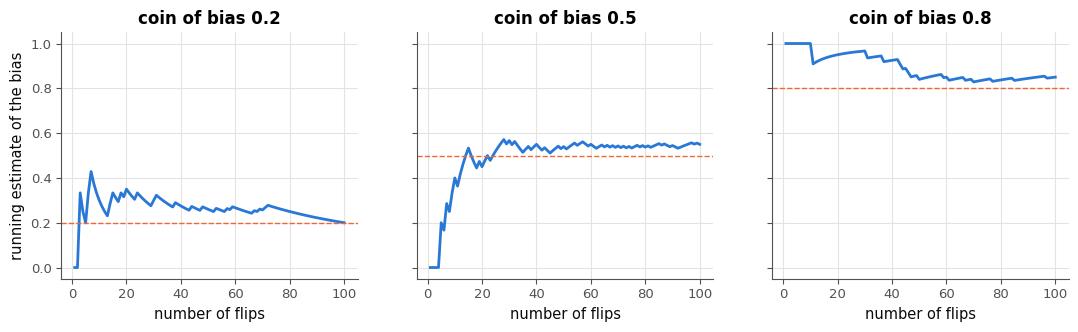

In [14]:
def running_estimate(flips):
    """Estimate of the bias after each flip: share of heads among the first k flips (k = 1, 2, ...)."""
    flips = np.asarray(flips)
    return np.cumsum(flips) / np.arange(1, len(flips) + 1)


curves_13 = {bias: running_estimate(flips) for bias, flips in flips_13.items()}
final_13 = [float(curves_13[bias][-1]) for bias in (0.2, 0.5, 0.8)]
max_error_13 = float(np.max(np.abs(curves_13[0.8][49:] - 0.8)))       # flips 50 to 100: indices 49 to 99
se_13 = float(np.sqrt(0.8 * 0.2 / 100))
print(final_13, max_error_13, se_13)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, (bias, curve) in zip(axes, curves_13.items()):
    ax.plot(np.arange(1, 101), curve, color="C0")
    ax.axhline(bias, color="C1", ls="--", lw=1)
    ax.set_title(f"coin of bias {bias}")
    ax.set_xlabel("number of flips")
axes[0].set_ylabel("running estimate of the bias")
plt.show()

In [15]:
wb.record("4.13a", final_13, decimals=4, mistakes={"l'ordre demandé est celui des biais 0,2, 0,5 et 0,8": final_13[::-1]})
wb.record("4.13b", max_error_13, decimals=3, mistakes={"tu as pris toute la série : on demande l'erreur du 50ᵉ au 100ᵉ lancer seulement": float(np.max(np.abs(curves_13[0.8] - 0.8)))})
wb.record("4.13c", se_13, decimals=3, mistakes={"c'est la variance : l'erreur typique est sa racine carrée": 0.8 * 0.2 / 100,
                                                 "tu n'as pas divisé par n": float(np.sqrt(0.8 * 0.2)),
                                                 "c'est la formule pour la pièce équilibrée : prends θ = 0,8": float(np.sqrt(0.25 / 100))})

WB_ANSWER {"decimals": 4, "element_coarse": [["5b3d8bf8a2ed390ca743a234c60339831e39f5f0addb351be05b7c8a11df1409"], ["f8a3c7f0292d0bc4dc1dca36824ed802c4ac992ada4b5f3e253ea04fe26d7125"], ["e1fe7d02096215b48dcd372ab04f5cc43c64f1b9e03474e5c44dc4d7cc2d6a71"]], "element_hashes": ["db94a9782088b2ae6025851ad3950564c4064ca8ee341762fa7c55095455beb1", "dd3cbb7487af72a083f61a52d297ace3cf7b3244d0db462adbe71679cfa69dc4", "6553b702c353ab98bb751a8a8951ad9db9d66ce47e566f7c48869630c4f3ca04"], "hash": "156d0335476a4ff905a4a7173d0ae66096998d96bfa0359d6dddddf51c0e479a", "id": "4.13a", "kind": "array", "mistakes": {"ca4630a6c7e3e1138593fd6b7623bf3e67251afbe207afd918d410fb428abbc8": "l'ordre demandé est celui des biais 0,2, 0,5 et 0,8"}, "shape": [3]}
📝 Ex 4.13a : réponse enregistrée (array, 4 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "40a0fbebc70d7015a57ff8b1f8c7c1d3e068bb41c30c76692a17aee35665a0f6", "hash_coarse": "faaab8a768490e0ed8ff534afe399e2fa718d279f28b17a6f9cc5d1cac1c6b55", "id": "4.13b", "kin

💡 La proportion de faces se stabilise, mais lentement : après 100 lancers, elle s'écarte encore typiquement de 0,04 du vrai biais, et 4 fois plus de lancers ne divisent cette erreur que par 2 (ch. 2). C'est une seule valeur, sans mesure de sa propre incertitude ; la suite du chapitre donne au contraire une distribution entière sur le biais, qui dit aussi à quel point on en est sûr.

### Ex 4.14 — evidence et bayes_posterior 🔨 ★★ ⏱️ 20 min
**Objectif :** écrire l'évidence et la règle de Bayes pour un nombre fini d'hypothèses, avec leurs contrôles.  
**Prérequis :** Ex 4.1 · fiche §4.4.1, §4.4.2 · **Fil rouge :** synthétique · **mylearn :** `bayes.py` · **Parcours :** R, M, C

> **Mode d'emploi mylearn** (comme aux chapitres précédents) : ouvre `mon_travail/mylearn/bayes.py` (créé par `python tools/start_chapter.py 4`), lis la docstring de chaque fonction, remplace les `raise NotImplementedError(...)` par ton code et **enregistre**. NumPy est permis (`np.asarray`, `np.dot`, `np.sum`, `np.log`, `np.exp`, `np.cumsum`…), SciPy non : `scipy.special` et `scipy.stats` sont les **oracles** des tests. Écris une petite fonction d'aide, par exemple `_check_distribution(p, name)`, qui convertit en tableau de flottants (`np.asarray(p, dtype=float)`), lève une `ValueError` s'il n'est pas à une dimension, s'il est vide, s'il contient une valeur négative ou un NaN, ou si sa somme s'écarte de 1 de plus de `1e-8`, et le renvoie : les fonctions du module l'appelleront. Teste les NaN à part, avec `np.isnan` : `nan < 0` vaut `False`, et une somme qui contient un NaN échappe aussi à la comparaison avec 1. La cellule de vérification recharge ta librairie, vérifie quelques valeurs, puis lance les tests de tes fonctions ; `python -m pytest tests/test_ch04_bayes.py -q` les lance tous dans un terminal.

Écris `evidence(prior, likelihood)` et `bayes_posterior(prior, likelihood)` (lis leurs docstrings) :
- valide les deux entrées : le prior est une distribution (valeurs positives ou nulles, de somme 1 à `1e-8` près) ; les vraisemblances sont des probabilités (entre 0 et 1), sans obligation de sommer à 1 ; les deux ont la même forme (attention : le broadcasting de NumPy étirerait sans rien dire un tableau de longueur 1) ;
- `evidence` renvoie un `float` Python, la somme des produits vraisemblance × prior ;
- `bayes_posterior` réutilise `evidence`, lève une `ValueError` si elle vaut 0 (l'observation est impossible sous toutes les hypothèses), puis renvoie le tableau des produits divisés par l'évidence, sans modifier les tableaux reçus.

Vérifications, sur un sac de trois pièces : une pièce équilibrée (prior 0,5), une de biais 0,3 (prior 0,25) et une de biais 0,9 (prior 0,25). On tire une pièce et on la lance : **pile**. La cellule de vérification appelle tes fonctions :
a) l'évidence $P(\text{pile})$ ;
b) le posterior des trois pièces ;
puis deux contrôles d'erreurs et les tests des deux fonctions.

In [16]:
prior_14 = np.array([0.5, 0.25, 0.25])            # fair coin, coin of bias 0.3, coin of bias 0.9
lik_tails_14 = 1 - np.array([0.5, 0.3, 0.9])      # P(tails | each coin)

In [17]:
evidence_14 = mylearn.bayes.evidence(prior_14, lik_tails_14)
posterior_14 = mylearn.bayes.bayes_posterior(prior_14, lik_tails_14)
print(evidence_14, posterior_14.round(4))
print(error_name(mylearn.bayes.bayes_posterior, [0.5, 0.5], [0.0, 0.0]), error_name(mylearn.bayes.evidence, [0.5, 0.6], [0.5, 0.5]))
run_bayes_tests("test_evidence_ or test_bayes_posterior_", impl="ref")

0.44999999999999996 [0.5556 0.3889 0.0556]
ValueError ValueError


pytest: 33 passed, 66 deselected in 0.74s


In [18]:
lik_heads_14 = np.array([0.5, 0.3, 0.9])
wb.record("4.14a", evidence_14, decimals=4, mistakes={"c'est l'évidence de FACE : on a observé pile": float(np.dot(prior_14, lik_heads_14)),
                                                       "tu as additionné les vraisemblances sans les pondérer par les priors": float(lik_tails_14.sum())})
wb.record("4.14b", posterior_14, decimals=4, mistakes={"tu n'as pas divisé par l'évidence": prior_14 * lik_tails_14,
                                                        "c'est le posterior après FACE : on a observé pile": prior_14 * lik_heads_14 / np.dot(prior_14, lik_heads_14)})

WB_ANSWER {"decimals": 4, "hash": "04ddda680919893811c0005c29d120d358dfbbdddec771a98b4c1b7e13fcf470", "hash_coarse": "cd8186e49e9b653b65755fa1f1a37a744dfc2192315aeff64692151ee6447f27", "id": "4.14a", "kind": "float", "magnitude": -1, "mistakes": {"6fb59fec5d5b26cd38e7f18f2fecef5910aaeec18f28a75785a7cdd3f919ccd2": "c'est l'évidence de FACE : on a observé pile", "adcc3756eb78c10cbed6430ea706cadbb29f37a5b8b84cfe0750998551783bf0": "tu as additionné les vraisemblances sans les pondérer par les priors"}, "sign": 1}
📝 Ex 4.14a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "element_coarse": [["37cbf2861c74c06a24beb2cf7acfad3f2c4a2574262224c59f326169e79e0230"], ["968bd3e67f469758b33e8474f1e8aef70927b9c5e0ec7789f231f401434c41c0"], ["e8d17dcc80341662745860858c4832a4199f3163cc95e1118f539aadcb69d14b"]], "element_hashes": ["0bc812766053efc90d11940b7667836241c4dd837d7f5cd3c30ec48d0fa1e1a2", "84f3fd4f406499d83f1f34f13531cca211660285dffd4a894b1dc65188977959", "04b2303999e580a3

💡 Pile fait tomber la pièce de biais 0,9 de 0,25 à environ 0,056 : elle ne donne pile qu'une fois sur dix, contre 7 fois sur 10 pour la pièce de biais 0,3, qui monte, elle, de 0,25 à 0,39. Les vraisemblances (0,5 ; 0,7 ; 0,1) somment à 1,3, et c'est normal : seule l'évidence (0,45) ramène le total à 1. La référence est dans `solutions/mylearn_ref/bayes.py` : lis-la **après** avoir réussi les tests.

### Ex 4.15 — Bayes chez les manchots : l'espèce sachant l'île 📦 ★★ ⏱️ 20 min
**Objectif :** retrouver une probabilité conditionnelle d'une table de contingence avec la règle de Bayes, puis la recalculer pour une autre population.  
**Prérequis :** Ex 4.14 · ch. 3 (Ex 3.14, `pd.crosstab`) · fiche §4.4.1, §4.5 · **Fil rouge :** Penguins · **Parcours :** R, C

Au ch. 3 (3.14), tu as lu $P(\text{espèce} \mid \text{île})$ directement dans la table espèce × île. Retrouve-la avec la règle de Bayes, en séparant ses deux ingrédients : la composition de la population (le **prior**) et l'endroit où vit chaque espèce (la **vraisemblance**).

Les hypothèses sont les trois espèces, toujours dans l'ordre `SPECIES` (Adelie, Chinstrap, Gentoo) ; l'observation est « le manchot a été vu sur l'île Dream ». Pour les 344 manchots de `penguins` :
a) `prior_15` : $P(\text{espèce})$, un tableau de trois probabilités (vérifié à 3 décimales, mais **n'arrondis pas** : c) à e) le réutilisent) ;
b) `likelihood_15` : $P(\text{Dream} \mid \text{espèce})$, un tableau de trois probabilités (vérifié à 3 décimales, sans arrondir non plus ; `pd.crosstab` et son argument `normalize` t'y aident) ;
c) vérifié avec ta fonction `bayes_posterior` : $P(\text{espèce} \mid \text{Dream})$ ; la vérification la compare à la colonne Dream de `pd.crosstab(..., normalize="columns")` ;
d) vérifié avec ta fonction `evidence` : $P(\text{Dream})$ ;
e) une autre équipe estime que, dans tout l'archipel, 60 % des manchots sont des Adélie, 15 % des Chinstrap et 25 % des Gentoo. Écris ce prior dans `other_prior_15` : la vérification calcule avec ta fonction $P(\text{espèce} \mid \text{Dream})$ pour cette population, avec les mêmes vraisemblances.

Dans tes notes : pourquoi peut-on garder les vraisemblances $P(\text{île} \mid \text{espèce})$ d'une population à l'autre, mais pas le prior ? Quand cette hypothèse serait-elle fausse ?

In [19]:
counts_15 = pd.crosstab(penguins["species"], penguins["island"]).reindex(SPECIES)
print(counts_15)
prior_15 = (counts_15.sum(axis=1) / counts_15.to_numpy().sum()).to_numpy()
likelihood_15 = pd.crosstab(penguins["species"], penguins["island"], normalize="index").reindex(SPECIES)["Dream"].to_numpy()
posterior_15 = mylearn.bayes.bayes_posterior(prior_15, likelihood_15)
evidence_15 = mylearn.bayes.evidence(prior_15, likelihood_15)
other_prior_15 = np.array([0.60, 0.15, 0.25])
other_posterior_15 = mylearn.bayes.bayes_posterior(other_prior_15, likelihood_15)
print(prior_15.round(3), likelihood_15.round(3), posterior_15.round(3), round(evidence_15, 4), other_posterior_15.round(3))

island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0
[0.442 0.198 0.36 ] [0.368 1.    0.   ] [0.452 0.548 0.   ] 0.3605 [0.596 0.404 0.   ]


In [20]:
counts_raw_15 = pd.crosstab(penguins["species"], penguins["island"]).reindex(SPECIES)
by_size_15 = penguins["species"].value_counts(normalize=True).to_numpy()     # sorted by decreasing count
wb.record("4.15a", prior_15, decimals=3, mistakes={"value_counts range les espèces par effectif décroissant : remets-les dans l'ordre Adelie, Chinstrap, Gentoo (sort_index ou reindex(SPECIES))": by_size_15,
                                                    "ce sont des effectifs : divise par le nombre de manchots": counts_raw_15.sum(axis=1).to_numpy()})
wb.record("4.15b", likelihood_15, decimals=3, mistakes={"c'est P(espèce | Dream) : la vraisemblance est P(Dream | espèce), divise chaque case par l'effectif de son ESPÈCE (normalize=\"index\")": counts_raw_15["Dream"].to_numpy() / counts_raw_15["Dream"].sum(),
                                                         "ce sont des effectifs : divise par l'effectif de chaque espèce": counts_raw_15["Dream"].to_numpy(),
                                                         "c'est la probabilité jointe P(espèce, Dream) : divise chaque case par l'effectif de son espèce, pas par le total": counts_raw_15["Dream"].to_numpy() / 344})
wb.record("4.15c", posterior_15, decimals=4)
wb.record("4.15d", evidence_15, decimals=4, mistakes={"c'est la somme des vraisemblances : pondère chacune par le prior de son espèce": float(likelihood_15.sum())})
wb.record("4.15e", other_posterior_15, decimals=4, mistakes={"c'est le posterior avec le prior des 344 manchots : utilise le prior de l'autre équipe": posterior_15})

WB_ANSWER {"decimals": 3, "element_coarse": [["c7a9cc104d2311daf5ac81f70f2827cd6b75770cfd6c4bfb398dbd04a1582ae7"], ["93d79bb2e1e4ce1b33a3d46398f4c8639c1dd45f92fb0d694de9f3aa95f7202c"], ["f4a02121ab1257f5aff5e159ecb4a14fc177927513bb469f1272ddf3d6d8ab50"]], "element_hashes": ["4e29d9ed85c7bb9b3cace81006eaa3692043c3514c50b83f0f8b7700433a9fff", "89ae6bf2da8478e61dc039801a2b99f7e24f00f4b7e515b0e27b0bc8a0cc29d1", "19e7beef741ce9590a276ce4a378cde3ced35e25a73e2ae0589b4c63f3b50677"], "hash": "162e65088040abeaf4d1b36795ad98cab08fd4e8833ce5cb9a1f89fa4db7b40f", "id": "4.15a", "kind": "array", "mistakes": {"5a4ce06daa6f9d4a6ca0b5303ee8f917c7cbb0a50c248239ca34c0380c16aa7a": "value_counts range les espèces par effectif décroissant : remets-les dans l'ordre Adelie, Chinstrap, Gentoo (sort_index ou reindex(SPECIES))", "9e23461a2ab105f0dc33278a8b4577f0c1525438bfe0b26099502fc2f05449d6": "ce sont des effectifs : divise par le nombre de manchots"}, "shape": [3]}
📝 Ex 4.15a : réponse enregistrée (array, 3 d

💡 La règle de Bayes ne dit rien de plus que la table : $P(\text{espèce} \mid \text{Dream})$ se lit aussi dans la colonne Dream. Son intérêt est de **séparer** deux ingrédients. La vraisemblance décrit où vit chaque espèce ; le prior décrit qui a été compté. Si l'échantillon de Palmer surreprésente une espèce, il suffit de changer le prior (e) : sur Dream, la part des Adélie passe de 0,45 à environ 0,60. Ce raisonnement suppose que $P(\text{île} \mid \text{espèce})$ reste vrai dans la nouvelle population : c'est faux si l'échantillonnage a privilégié certaines îles pour certaines espèces, par exemple. C'est le même raisonnement que la precision d'un test, recalculée pour une autre prévalence (ch. 3).

## Partie B · La boucle posterior → prior

Fiche §4.5 à §4.6.2 et « au-delà du livre (1) ». Tu écris la mise à jour séquentielle (`update_discrete`), tu refais les barres empilées du livre, tu observes un underflow et tu le corriges, puis tu balaies une grille de pièces et tu envoies des sondes jusqu'à la décision.

### Ex 4.16 — La boucle posterior-prior : update_discrete 🔨 ★★ ⏱️ 30 min
**Objectif :** écrire la mise à jour séquentielle d'une distribution sur des hypothèses, observation après observation.  
**Prérequis :** Ex 4.14 · fiche §4.6, §4.6.1 · **Fil rouge :** synthétique · **mylearn :** `bayes.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/bayes.py`, mêmes règles qu'en 4.14 (NumPy permis, SciPy non). Enregistre, puis relance la cellule de vérification.

Écris `update_discrete(prior, likelihoods, observations, return_history=False)` (lis sa docstring) :
- `likelihoods` est un **tableau** : une ligne par hypothèse, une colonne par issue possible, `likelihoods[i, o]` $= P(\text{issue } o \mid H_i)$. Pour une pièce, deux colonnes (0 = pile, 1 = face) ;
- `observations` contient des **indices d'issues** ; pour chacune, la colonne correspondante donne les vraisemblances, la règle de Bayes (ta fonction `bayes_posterior`) donne le posterior, et ce posterior devient le prior de l'observation suivante ;
- valide tout : un tableau à deux dimensions avec une ligne par hypothèse, des indices entiers entre 0 et le nombre d'issues moins 1 (attention : NumPy accepterait l'indice −1 sans rien dire, il lit alors la dernière colonne) ;
- sans aucune observation (`[]`), elle renvoie le prior ; avec `return_history=True`, elle renvoie un tableau dont la ligne 0 est le prior et la ligne $k$ le posterior après les $k$ premières observations.

Vérifications, sur trois dés possibles (`DICE_16`) : un dé équilibré, un dé pipé sur le 6 et un dé pipé sur le 1, avec le prior `prior_16`. On lance le dé cinq fois : les faces sont dans `rolls_16` (la face $k$ est l'issue d'indice $k - 1$). La cellule de vérification appelle ta fonction :
a) le posterior final des trois dés ;
b) le posterior après les deux premiers lancers (la ligne 2 de l'historique) ;
c) `most_likely_16` : après les cinq lancers, quel dé est le plus probable ? Réponds par son numéro de ligne (0, 1 ou 2), en lisant le résultat que la vérification affiche.

Puis un contrôle (l'ordre des lancers ne change rien), un contrôle d'erreur et les tests de `update_discrete`.

In [21]:
DICE_16 = np.array([[1 / 6] * 6,                       # 0: a fair die
                    [0.1, 0.1, 0.1, 0.1, 0.1, 0.5],    # 1: a die loaded on the 6
                    [0.5, 0.1, 0.1, 0.1, 0.1, 0.1]])   # 2: a die loaded on the 1
prior_16 = np.array([0.8, 0.1, 0.1])
rolls_16 = np.array([6, 6, 2, 6, 5])                   # the faces rolled

In [22]:
final_16 = mylearn.bayes.update_discrete(prior_16, DICE_16, rolls_16 - 1)
history_16 = mylearn.bayes.update_discrete(prior_16, DICE_16, rolls_16 - 1, return_history=True)
print(history_16.round(4))
most_likely_16 = int(np.argmax(final_16))
run_bayes_tests("test_update_discrete_", impl="ref")

[[0.8    0.1    0.1   ]
 [0.6897 0.2586 0.0517]
 [0.4608 0.5184 0.0207]
 [0.5875 0.3966 0.0159]
 [0.3288 0.6659 0.0053]
 [0.4495 0.5461 0.0044]]


pytest: 21 passed, 78 deselected in 0.65s


In [23]:
wb.record("4.16a", final_16, decimals=4)
wb.record("4.16b", history_16[2], decimals=4, mistakes={"c'est la ligne 1 : la ligne 0 est le prior, la ligne 2 le posterior après DEUX lancers": history_16[1],
                                                         "c'est la ligne 3 : la ligne 0 est le prior, la ligne 2 le posterior après DEUX lancers": history_16[3]})
wb.record("4.16c", most_likely_16, mistakes={"c'est le dé le plus probable AVANT les lancers (le prior) : lis le posterior final": 0,
                                              "ce dé est pipé sur le 1 : combien de 1 a-t-on vus ?": 2})

WB_ANSWER {"decimals": 4, "element_coarse": [["b6127c7857fa708e320cac6c36865154cf9e86d770cc29b76e40347ab01ef6b1"], ["500be58b124d54ff899ca1d68159ba7cff7433ee4dfaf6dccba06eb2c92bf0a9"], ["f1555462cb679ac1a82fdc56d793cffe5bca060737f6644e2d4df134aa82a081"]], "element_hashes": ["1135394b2bb8f0da53d7d2f4358c49fefb9720314bf7a5410c54dd8b866bfaae", "9cb9c9d8ebc647e043c3d5ba8e5a7ba7cf20c830c79d56b60947cb1ad8ca67f9", "06f86d1cb3a9efff97e3fbcc2beb0ddc613b05aa667be723212d48d31e91236b"], "hash": "3ebd03a9df24de707a7861b7248150d2ecf706ec339a5deedbafa4a361cc5b30", "id": "4.16a", "kind": "array", "shape": [3]}
📝 Ex 4.16a : réponse enregistrée (array, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "element_coarse": [["b2ad31f1ba67d4a90a84b2090a79ea6acd5a34b3a5f3aa3471d7016dd7bb5e15"], ["49943cbe12e54f7a82381bc5400dffb8c234af40b29ac223bb0cb1386135bf50"], ["76baca2db286ce57509c99141fb7a20905cde89d39487bb84fac4f5163ef8c9f"]], "element_hashes": ["c4e9d8f53c57bdadb9300be938e6e8d61b2c43fa4e8acf27eb6ed6d6deaa9b8c"

💡 Trois 6 en cinq lancers : le dé pipé sur le 6 passe de 10 % à environ 55 %, devant le dé équilibré (45 %), malgré un prior qui donnait 8 chances sur 10 au dé équilibré. Le dé pipé sur le 1 s'effondre (moins de 1 %) : aucun 1 n'est sorti. La même fonction sert à tout problème où l'on peut écrire un tableau hypothèses × issues : pièces, dés, sondes (4.20), et 501 hypothèses sur un biais (4.21).

### Ex 4.17 — Reproduire les trente lancers de la figure 4.24 🎨 ★★ ⏱️ 25 min
**Objectif :** tracer, lancer après lancer, la probabilité de chacune de deux pièces en barres empilées.  
**Prérequis :** Ex 4.16 · fiche §4.6.2 · livre §4.6.2 (figures 4.24 à 4.26) · **Fil rouge :** synthétique · **Parcours :** C

Le livre suit, lancer après lancer, la probabilité d'avoir la pièce équilibrée plutôt qu'une pièce de biais 0,2 (prior 0,5 chacune), en barres empilées (figures 4.24 à 4.26). Refais ses trois figures avec les trois suites de 30 lancers de `SEQUENCES_17` (des chaînes de caractères : `"F"` pour face, `"P"` pour pile), qui contiennent 6, 3 et 24 faces.

1. Écris `stacked_history_17(sequence)` : elle convertit la chaîne en tableau d'issues (1 pour `"F"`, 0 pour `"P"`), puis renvoie l'historique de `mylearn.bayes.update_discrete`, un tableau de forme `(31, 2)` dont la colonne 0 est $P(\text{équilibrée})$ et la colonne 1 $P(\text{truquée})$.
2. Écris `draw_stacked_17(ax, sequence)` : sur l'axe `ax`, des barres de hauteur $P(\text{équilibrée})$, puis, empilées au-dessus (`bottom=`), des barres de hauteur $P(\text{truquée})$ ; en abscisse, « avant » puis la lettre de chaque lancer.

La vérification contrôle ton historique, puis trace les trois panneaux avec ta fonction. Compare avec le livre, puis note dans tes notes après combien de lancers la pièce truquée dépasse 0,9 dans la suite à 3 faces.

In [24]:
SEQUENCES_17 = {"6 heads": "PPPPPFFFPPPPPPPPPPFPPPFFPPPPPP",     # F = face (heads), P = pile (tails)
                "3 heads": "PPPPFPPPPPPPPPPFPPPPPPPPPFPPPP",
                "24 heads": "PFFPFFFFFPFFFFFFFFFFPFFFPFFFPF"}
COINS_17 = np.array([[0.5, 0.5],      # fair coin: P(tails), P(heads)
                     [0.8, 0.2]])     # rigged coin, bias 0.2

first flip with P(rigged) > 0.9 in the 3-heads run: 8


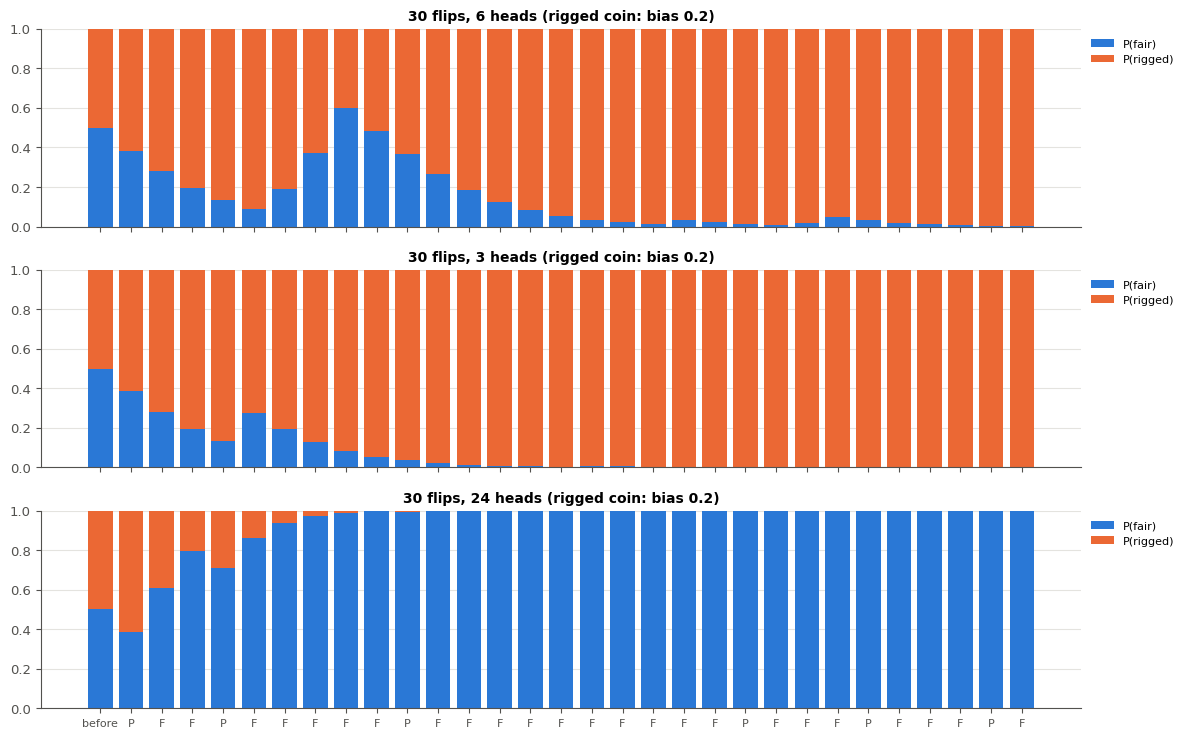

In [25]:
def stacked_history_17(sequence):
    """(31, 2) array: P(fair) and P(rigged) before the flips, then after each flip of `sequence`."""
    flips = np.array([1 if c == "F" else 0 for c in sequence])
    return mylearn.bayes.update_discrete([0.5, 0.5], COINS_17, flips, return_history=True)


def draw_stacked_17(ax, sequence):
    """Stacked bars of P(fair) (bottom) and P(rigged) (top), one bar before the flips and one per flip."""
    history = stacked_history_17(sequence)
    x = np.arange(len(history))
    ax.bar(x, history[:, 0], color="C0", label="P(fair)")
    ax.bar(x, history[:, 1], bottom=history[:, 0], color="C1", label="P(rigged)")
    ax.set_xticks(x)
    ax.set_xticklabels(["before"] + list(sequence), fontsize=8)
    ax.set_ylim(0, 1)
    ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8)


history_3_17 = stacked_history_17(SEQUENCES_17["3 heads"])
print("first flip with P(rigged) > 0.9 in the 3-heads run:", int(np.argmax(history_3_17[:, 1] > 0.9)))
fig, axes = plt.subplots(3, 1, figsize=(12, 7.5), sharex=True)
for ax, (label, sequence) in zip(axes, SEQUENCES_17.items()):
    draw_stacked_17(ax, sequence)
    ax.set_title(f"30 flips, {label} (rigged coin: bias 0.2)", fontsize=10)
plt.tight_layout()
plt.show()

💡 Dans la suite à 3 faces, la pièce truquée dépasse 0,9 après 8 lancers : quatre piles de suite la portent à 0,87, la face du 5ᵉ lancer la fait redescendre à 0,72, puis trois piles la font passer à 0,91. Chaque pile multiplie la cote « truquée contre équilibrée » par $\frac{0{,}8}{0{,}5} = 1{,}6$ ; chaque face la divise par $\frac{0{,}5}{0{,}2} = 2{,}5$. Avec 24 faces, la pièce équilibrée l'emporte, alors que 24 faces sur 30 sont aussi très rares pour elle : Bayes compare les hypothèses entre elles, il ne dit pas si l'une d'elles est bonne (fiche §4.6.2).

### Ex 4.18 — Le posterior qui s'évanouit : underflow 🐛 ★★ ⏱️ 20 min
**Objectif :** diagnostiquer un posterior qui devient `nan`, et le corriger en passant aux log-probabilités.  
**Prérequis :** Ex 4.16 · fiche, au-delà du livre (1) (🧮 underflow, log-sum-exp) · 0B (logarithmes) · **Fil rouge :** synthétique · **Parcours :** R, M, C

Un collègue estime le biais d'une pièce parmi trois candidats (0,58 ; 0,60 ; 0,62), avec la fonction `posterior_after_flips` ci-dessous : elle multiplie toutes les vraisemblances, puis normalise une seule fois à la fin. Sur 200 lancers, tout va bien ; sur 3 000, elle renvoie `[nan nan nan]`.

a) `n_zero_18` : le plus petit entier $n$ pour lequel `0.5 ** n == 0.0` en Python (cherche-le avec une boucle) ;
b) `first_nan_18` : le plus petit nombre de lancers $k$ pour lequel `posterior_after_flips(prior_18, biases_18, flips_18[:k])` contient des `nan`. Inutile de l'appeler 3 000 fois : calcule d'un coup, avec `np.cumprod`, le tableau `joint` de la fonction (le prior multiplié par le produit des vraisemblances) après chaque lancer, et cherche quand il devient exactement 0 pour **chacune** des trois hypothèses ;
c) corrige : écris `posterior_fixed_18(prior, biases, flips)`, avec le même contrat mais en log-probabilités. Additionne $\log P(\theta)$, $h \log\theta$ et $t \log(1 - \theta)$, retranche le maximum, puis prends l'exponentielle et normalise (fiche, 🧮 log-sum-exp). La vérification compare ta version à celle du collègue sur 200 lancers, puis vérifie ton posterior après les 3 000 lancers ;
d) `lse_18` : sans SciPy, avec l'astuce du maximum, $\log(e^{-1000} + e^{-1001})$ (3 décimales).

Dans tes notes : pourquoi le calcul direct de d) échoue-t-il ? Pourquoi aucune erreur n'apparaît-elle au moment où le produit devient 0 ?

In [26]:
def posterior_after_flips(prior, biases, flips):
    """Posterior over the candidate biases after the flips (the colleague's version)."""
    prior, biases = np.asarray(prior, dtype=float), np.asarray(biases, dtype=float)
    likelihood = np.ones(len(biases))                  # P(all the flips so far | each bias)
    for flip in flips:
        likelihood = likelihood * (biases if flip == 1 else 1 - biases)
    joint = prior * likelihood
    return joint / joint.sum()


biases_18 = np.array([0.58, 0.60, 0.62])
prior_18 = np.full(3, 1 / 3)
flips_18 = wb.synth.coin_flips(3000, 0.6, seed=25)
with np.errstate(invalid="ignore"):                    # silence the 0 / 0 warning
    print("after 200 flips: ", posterior_after_flips(prior_18, biases_18, flips_18[:200]).round(4))
    print("after 3000 flips:", posterior_after_flips(prior_18, biases_18, flips_18))

after 200 flips:  [0.2407 0.3638 0.3955]
after 3000 flips: [nan nan nan]


In [27]:
n_zero_18 = 1
while 0.5 ** n_zero_18 != 0.0:
    n_zero_18 += 1

likelihoods_18 = np.cumprod(np.where(flips_18[:, None] == 1, biases_18, 1 - biases_18), axis=0)   # row k-1: k flips
joints_18 = prior_18 * likelihoods_18                     # the `joint` of the colleague's function, after each flip
first_nan_18 = int(np.argmax((joints_18 == 0).all(axis=1))) + 1


def posterior_fixed_18(prior, biases, flips):
    """Same contract as posterior_after_flips, computed with log-probabilities (no underflow)."""
    prior, biases, flips = np.asarray(prior, dtype=float), np.asarray(biases, dtype=float), np.asarray(flips)
    heads = int(flips.sum())
    tails = len(flips) - heads
    log_post = np.log(prior) + heads * np.log(biases) + tails * np.log(1 - biases)
    weights = np.exp(log_post - log_post.max())
    return weights / weights.sum()


fixed_18 = posterior_fixed_18(prior_18, biases_18, flips_18)
logs_18 = np.array([-1000.0, -1001.0])
lse_18 = float(logs_18.max() + np.log(np.sum(np.exp(logs_18 - logs_18.max()))))
print(n_zero_18, first_nan_18, fixed_18.round(4), lse_18, special.logsumexp(logs_18))

1075 1099 [0.0785 0.8586 0.0629] -999.6867383124818 -999.6867383124818


In [28]:
wb.record("4.18a", n_zero_18, mistakes={"c'est le premier n où 0.5 ** n passe sous le plus petit nombre NORMAL (environ 2,2e-308) : en dessous, les nombres dénormalisés existent encore, cherche quand le résultat vaut exactement 0": 1023,
                                         "c'est le dernier n où 0.5 ** n n'est pas encore nul : on demande le premier où il vaut 0": n_zero_18 - 1})
wb.record("4.18b", first_nan_18, mistakes={"c'est le moment où le produit d'UNE hypothèse devient nul : il faut que les trois le soient pour obtenir 0 / 0": int(np.argmax((joints_18 == 0).any(axis=1))) + 1,
                                            "tu as regardé les produits de vraisemblances seuls : la fonction les multiplie encore par le prior, et c'est ce produit-là (joint) qui doit valoir 0": int(np.argmax((likelihoods_18 == 0).all(axis=1))) + 1,
                                            "c'est un indice qui commence à 0 : on demande un nombre de lancers": first_nan_18 - 1})
wb.record("4.18c", fixed_18, decimals=4, mistakes={"vérifie le sens des deux termes : h log θ pour les faces (1), t log(1 − θ) pour les piles (0)": posterior_fixed_18(prior_18, 1 - biases_18, flips_18)})
wb.record("4.18d", lse_18, decimals=3, mistakes={"tu n'as gardé que le maximum : il manque le log de la somme des exponentielles décalées": -1000.0,
                                                  "tu as additionné les deux logarithmes : c'est le log du PRODUIT, pas de la somme": -2001.0,
                                                  "tu n'as gardé que la plus petite des deux valeurs : le log d'une somme d'exponentielles dépasse même la plus grande": -1001.0})

WB_ANSWER {"hash": "d9611fde470f3b6ed541a814e562106d409598122777f8f175f1ce0b316ee31b", "id": "4.18a", "kind": "int", "magnitude": 3, "mistakes": {"6a07d6593075e066d962d85ff1f94ed01b674218d2352eb2567cd1d1d42a7f32": "c'est le premier n où 0.5 ** n passe sous le plus petit nombre NORMAL (environ 2,2e-308) : en dessous, les nombres dénormalisés existent encore, cherche quand le résultat vaut exactement 0", "86de384c64b0172dc0a5a6c7c4e6a6267573c8b31d0cbccd7c7f7afffb097a87": "c'est le dernier n où 0.5 ** n n'est pas encore nul : on demande le premier où il vaut 0"}, "sign": 1}
📝 Ex 4.18a : réponse enregistrée (int).
WB_ANSWER {"hash": "3d9e18c2c537211046d4a091781ad7ae63cff1a56a10bf3f4c8d88da7b0599d6", "id": "4.18b", "kind": "int", "magnitude": 3, "mistakes": {"cf8869cc8c53fcbc7ff08c61dc562c2505fad2696c9a06a91adae1b38fa97794": "c'est un indice qui commence à 0 : on demande un nombre de lancers", "dfd1c920ec805a430555559ce1ffc9094321f750da23487c43b72c2f0b7d5645": "c'est le moment où le produit

💡 Un produit de probabilités plus petites que 1 décroît exponentiellement. Après environ 1 100 lancers, les trois produits sont arrondis à 0, et la normalisation calcule 0 / 0. Rien ne prévient au moment de l'underflow : la multiplication renvoie 0 sans erreur, et seul le `nan` final signale le problème, bien plus tard. En logarithmes, $-1\,000$ ou $-2\,000$ se représentent sans problème ; après soustraction du maximum, l'hypothèse la plus probable vaut $e^0 = 1$, et les autres sont des rapports raisonnables. Après 3 000 lancers, le vrai biais (0,60) l'emporte nettement, mais ses deux voisins (0,58 et 0,62), très proches, gardent chacun quelques pour cent : 3 000 lancers ne suffisent pas à les exclure.

### Ex 4.19 — La grille biais × proportion de faces 🔬 ★★ ⏱️ 30 min
**Objectif :** mesurer, sur une grille de pièces et de séries de lancers, quand Bayes sait trancher et quand il hésite.  
**Prérequis :** Ex 4.16 · fiche §4.6.2 · livre §4.6.2 (figures 4.27 et 4.28) · **Fil rouge :** synthétique · **Parcours :** C

Le livre balaie une grille (figures 4.27 et 4.28) : en abscisse le biais de la pièce truquée, en ordonnée la proportion de faces d'une série de lancers inventée ; dans chaque case, la probabilité finale que la pièce soit l'équilibrée (prior 0,5 chacune). Refais-la avec les dix proportions `PROPORTIONS_19` et les dix biais `BIASES_19` (0,05 ; 0,15 ; … ; 0,95).

Écris `grid_19(n)`, qui renvoie un tableau $10 \times 10$ : la case `[i, j]` vaut $P(\text{équilibrée} \mid \text{lancers})$ pour une série de $n$ lancers contenant `round(PROPORTIONS_19[i] * n)` faces, quand la pièce truquée a le biais `BIASES_19[j]`. Le posterior ne dépend que du nombre de faces (4.16) : prends la série `[1] * h + [0] * (n - h)` et ta fonction `update_discrete`.

a) vérifié avec ta fonction : `grid_19(40)` ;
b) `decided_19` : une case est « tranchée » si $P(\text{équilibrée})$ y est inférieure à 0,05 ou supérieure à 0,95. Combien de cases sont tranchées pour $n = 40$, puis pour $n = 1\,000$ ? (une liste de deux entiers).

La vérification trace les deux grilles (ligne 0 en bas). Dans tes notes : où se trouvent les cases indécises ? Que se passe-t-il dans le coin où l'on observe 95 % de faces avec une pièce truquée de biais 0,05 ? Est-ce rassurant ?

In [29]:
PROPORTIONS_19 = (2 * np.arange(10) + 1) / 20    # 0.05, 0.15, ..., 0.95: share of heads of the flips (rows)
BIASES_19 = PROPORTIONS_19.copy()                 # bias of the rigged coin (columns)

[[0.   0.   0.   0.   0.03 0.98 1.   1.   1.   1.  ]
 [0.   0.   0.   0.   0.07 0.95 1.   1.   1.   1.  ]
 [0.98 0.02 0.01 0.01 0.14 0.9  1.   1.   1.   1.  ]
 [1.   0.96 0.3  0.14 0.27 0.8  1.   1.   1.   1.  ]
 [1.   1.   0.97 0.66 0.45 0.65 0.96 1.   1.   1.  ]
 [1.   1.   1.   0.96 0.65 0.45 0.66 0.97 1.   1.  ]
 [1.   1.   1.   1.   0.8  0.27 0.14 0.3  0.96 1.  ]
 [1.   1.   1.   1.   0.9  0.14 0.01 0.01 0.02 0.98]
 [1.   1.   1.   1.   0.95 0.07 0.   0.   0.   0.  ]
 [1.   1.   1.   1.   0.98 0.03 0.   0.   0.   0.  ]] [80, 100]


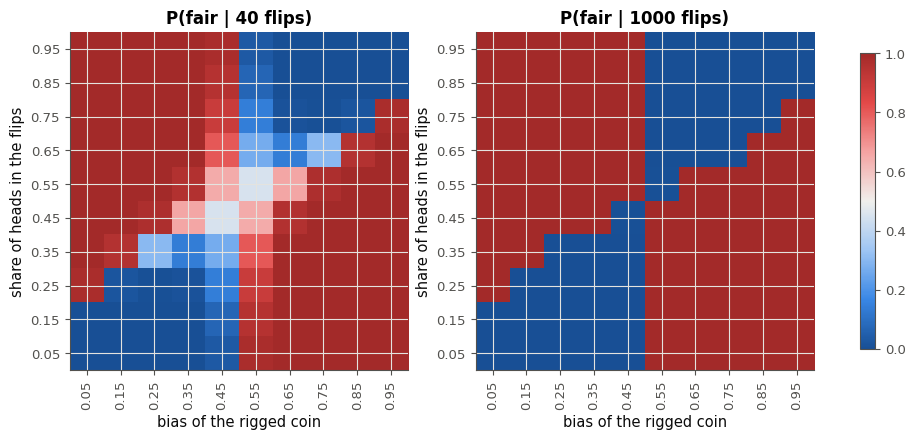

In [30]:
def grid_19(n):
    """10 x 10 array: P(fair | n flips with round(p * n) heads); row = proportion p, column = rigged bias."""
    grid = np.zeros((10, 10))
    for i, proportion in enumerate(PROPORTIONS_19):
        heads = round(proportion * n)
        flips = np.array([1] * heads + [0] * (n - heads))
        for j, bias in enumerate(BIASES_19):
            table = np.array([[0.5, 0.5], [1 - bias, bias]])      # rows: fair, rigged; columns: tails, heads
            grid[i, j] = mylearn.bayes.update_discrete([0.5, 0.5], table, flips)[0]
    return grid


grids_19 = {n: grid_19(n) for n in (40, 1000)}
decided_19 = [int(np.sum((grid < 0.05) | (grid > 0.95))) for grid in grids_19.values()]
print(grids_19[40].round(2), decided_19)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, (n, grid) in zip(axes, grids_19.items()):
    image = ax.imshow(grid, origin="lower", cmap=wb.plot.diverging_cmap(), vmin=0, vmax=1)
    ax.set_xticks(range(10), [f"{b:.2f}" for b in BIASES_19], rotation=90)
    ax.set_yticks(range(10), [f"{p:.2f}" for p in PROPORTIONS_19])
    ax.set_xlabel("bias of the rigged coin")
    ax.set_ylabel("share of heads in the flips")
    ax.set_title(f"P(fair | {n} flips)")
fig.colorbar(image, ax=axes, shrink=0.8)
plt.show()

In [31]:
wb.record("4.19a", grids_19[40], decimals=4)
wb.record("4.19b", decided_19, mistakes={"tu as compté les cases INDÉCISES : on demande les cases tranchées": [100 - k for k in decided_19],
                                          "l'ordre demandé est [n = 40, n = 1 000]": decided_19[::-1]})

⚠️ Ex 4.19a : un élément est proche d'une limite d'arrondi ; envisage un autre nombre de décimales.
WB_ANSWER {"decimals": 4, "element_coarse": [["62d2d9fa4b67b1590227c1859063701d36a380c8bcae9a3576d320131f540f58"], ["7b83e83537278bc60acc58654b923fadb2b20ba6c76f6482d6cbdec19b1e9e6a"], ["507e97f6efa2d1ece77ad74526fad10bf3a5a1a37e6f95e2c21ad99d2246f3e8"], ["0eebd480bb5102cd448f1fdc1d70cae2a34bc6a10da41b752ab0bb6ef5a222cb"], ["6eddbe2464698d416be46a1c024d9905306c21607c901679b06a2d24a43bd9bd"], ["701d2cc3d1101c15ab97884e98ff8451b0211db3ba481d3bc5c5017be23c86ba"], ["5acde8cd972d16d7780a1673170265bd677bea4cb13ade9e947448f0bceecfca"], ["95dbf3072ebb1c82e05823558b25ad1ae98855475c90f0e3428bf57977cbd6d5"], ["ed92d44076d27fa9e81edee72f4a1221e4f61136abac3eaade09cc8b2069fad3"], ["b6d84042b55b011d945d82e91d9cb770094420b5ab8414cf720c6d9f3408b377"], ["ea12fcb42f71ef889166f97840376d6d34e59c84f55330a67f4823837085c75c"], ["2983d306824d00b3a657619f19fbae6e48cdf52596f53c66a0473d5b8e2eeb5d"], ["e23f107ba0a87

💡 Avec 40 lancers, 20 cases sur 100 restent indécises : surtout dans les deux colonnes centrales, où la pièce truquée a un biais de 0,45 ou 0,55 (presque une pièce équilibrée : 40 lancers ne suffisent pas à les distinguer, pour la plupart des proportions de faces), et quelques cases voisines, où le biais de la pièce truquée reste proche de 0,5 et de la proportion observée. Avec 1 000 lancers, toutes les cases sont tranchées. Mais regarde le coin en haut à gauche : 95 % de faces, avec une pièce truquée de biais 0,05. Bayes y est **certain** que la pièce est équilibrée, alors qu'aucune des deux hypothèses ne peut produire une telle série. Plus de données rendent plus sûr… de la moins mauvaise des hypothèses proposées. Vérifier que le modèle lui-même tient la route (ici, comparer 95 % à 50 %) reste indispensable.

### Ex 4.20 — Envoyer des sondes jusqu'à la décision 🔬 ★★ ⏱️ 25 min
**Objectif :** simuler une décision séquentielle : envoyer des sondes une par une jusqu'à être assez sûr, et compter les erreurs.  
**Prérequis :** Ex 4.4, Ex 4.16 · fiche §4.5, §4.6.1 · **Fil rouge :** synthétique · **Parcours :** C

On reprend la sonde Argos-2 de l'exercice 4.4 (sa sensibilité `SENS_20` et sa spécificité `SPEC_20` viennent de son tableau de test), dans la région où 5 % des planètes sont habitées. Pour chaque planète, le capitaine envoie des sondes **une par une**. Après chaque sonde, il met à jour $P(\text{habitée})$ ; il décide d'exploiter la planète dès que $P(\text{habitée}) < 10^{-6}$, et de la protéger dès que $P(\text{habitée}) > 0{,}99$. Les sondes sont supposées indépendantes sachant l'état de la planète.

Écris `explore_20(inhabited, rng)`, qui renvoie `(decision, probes)` : `"mine"` ou `"protect"`, et le nombre de sondes envoyées (au plus 20 ; au-delà, `"undecided"`). Pour que tout le monde obtienne les mêmes nombres, **tire exactement ainsi** : un seul `rng.random()` par sonde, au moment où tu l'envoies (ne tire pas les vingt d'avance) ; `detected = rng.random() < SENS_20` si la planète est habitée, `rng.random() < 1 - SPEC_20` sinon. Mets à jour avec ta fonction `update_discrete` et le tableau `TABLE_20` (une ligne par hypothèse : habitée, stérile ; une colonne par issue : 0 = rien, 1 = détecté, et `int(detected)` donne l'issue), en partant du prior `[PRIOR_20, 1 - PRIOR_20]`. La première sonde envoyée compte pour 1.

La vérification simule 10 000 planètes avec `simulate_20(explore_20)`, qui tire d'abord l'état de chaque planète, puis appelle ta fonction avec le même générateur. Vérifié avec ta fonction :
a) le nombre moyen de sondes par planète ;
b) le nombre de planètes protégées ;
c) le nombre de planètes stériles protégées par erreur.

Dans tes notes : combien de planètes habitées ont été exploitées ? Pourquoi ce nombre était-il prévisible ? Que deviendrait-il si deux sondes avaient tendance à se tromper ensemble (4.8 g) ?

In [32]:
SENS_20, SPEC_20 = 240 / 250, 1645 / 1750         # the probe Argos-2 of 4.4 (from its test table)
PRIOR_20 = 0.05                                   # the same region
TABLE_20 = np.array([[1 - SENS_20, SENS_20],      # inhabited planet: P(nothing), P(detected)
                     [SPEC_20, 1 - SPEC_20]])     # sterile planet:   P(nothing), P(detected)


def simulate_20(explore, n_planets=10_000, seed=20):
    """Explore n_planets planets with `explore`; one generator for everything, in a fixed order."""
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n_planets):
        inhabited = bool(rng.random() < PRIOR_20)        # one draw for the planet...
        decision, probes = explore(inhabited, rng)       # ...then one draw per probe, inside explore
        rows.append((inhabited, decision, probes))
    return pd.DataFrame(rows, columns=["inhabited", "decision", "probes"])

In [33]:
def explore_20(inhabited, rng, low=1e-6, high=0.99, max_probes=20):
    """Send probes one by one until a decision: ("mine", "protect" or "undecided", number of probes sent)."""
    posterior = np.array([PRIOR_20, 1 - PRIOR_20])
    for probes in range(1, max_probes + 1):
        detected = rng.random() < (SENS_20 if inhabited else 1 - SPEC_20)
        posterior = mylearn.bayes.update_discrete(posterior, TABLE_20, [int(detected)])
        if posterior[0] < low:
            return "mine", probes
        if posterior[0] > high:
            return "protect", probes
    return "undecided", max_probes


planets_20 = simulate_20(explore_20)
mean_probes_20 = float(planets_20["probes"].mean())
protected_20 = int((planets_20["decision"] == "protect").sum())
wrongly_protected_20 = int(((planets_20["decision"] == "protect") & ~planets_20["inhabited"]).sum())
with wb.attempt("4.20"):
    print(f"probes per planet: mean {planets_20['probes'].mean():.3f}, at most {planets_20['probes'].max()}")
    print(pd.crosstab(planets_20["inhabited"], planets_20["decision"], margins=True))

probes per planet: mean 4.464, at most 13
decision   mine  protect    All
inhabited                      
False      9533        4   9537
True          0      463    463
All        9533      467  10000


In [34]:
def explore_predrawn_20(inhabited, rng, low=1e-6, high=0.99, max_probes=20):
    """The classic mistake: the draws of all the probes made in advance."""
    draws = rng.random(max_probes)
    posterior = np.array([PRIOR_20, 1 - PRIOR_20])
    for probes in range(1, max_probes + 1):
        detected = draws[probes - 1] < (SENS_20 if inhabited else 1 - SPEC_20)
        posterior = mylearn.bayes.update_discrete(posterior, TABLE_20, [int(detected)])
        if posterior[0] < low:
            return "mine", probes
        if posterior[0] > high:
            return "protect", probes
    return "undecided", max_probes


predrawn_20 = simulate_20(explore_predrawn_20)
in_advance_20 = "tu as tiré les nombres d'avance : un seul rng.random() par sonde, au moment où tu l'envoies"
wb.record("4.20a", mean_probes_20, decimals=4, mistakes={"tu as compté les sondes à partir de 0 : la première sonde envoyée compte pour 1": mean_probes_20 - 1,
                                                          in_advance_20: float(predrawn_20["probes"].mean())})
wb.record("4.20b", protected_20, mistakes={"c'est le nombre de planètes habitées : certaines planètes stériles sont protégées aussi": int(planets_20["inhabited"].sum()),
                                            in_advance_20: int((predrawn_20["decision"] == "protect").sum())})
wb.record("4.20c", wrongly_protected_20, mistakes={in_advance_20: int(((predrawn_20["decision"] == "protect") & ~predrawn_20["inhabited"]).sum())})

WB_ANSWER {"decimals": 4, "hash": "9b92db2934febeec627f4739a3a5cd38e762bfa8be1a73f2b5f3a18c68d9a206", "hash_coarse": "82e4e61735f035424c496097316867f1147ba369d1c1b2a04738465b93be03f5", "id": "4.20a", "kind": "float", "magnitude": 0, "mistakes": {"3225838357fe32047f7492730fc2caa9d9cc5f84a1a7d8e1f88011b3e0bca269": "tu as tiré les nombres d'avance : un seul rng.random() par sonde, au moment où tu l'envoies", "f2ff410cad6b83edb61b846207ecf35caf0a2da5c0e98c60d54b7c3d9e740b44": "tu as compté les sondes à partir de 0 : la première sonde envoyée compte pour 1"}, "sign": 1}
📝 Ex 4.20a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"hash": "45538c7c753b8ea397f28679c2a9ad73788d79013c69b377924ff8c12ead00c9", "id": "4.20b", "kind": "int", "magnitude": 2, "mistakes": {"0baf82a1235e594e1cd22b5d0853816551302d395b83d7d766c3fd93a2315ea9": "tu as tiré les nombres d'avance : un seul rng.random() par sonde, au moment où tu l'envoies", "975dd15a8e9fd2099ab164ebc1824874219fe3b425d02ee5f0e77f1589f85

💡 En moyenne, moins de cinq sondes suffisent : quatre sondes négatives de suite font passer une planète sous un millionième (4.8), et trois positives au-dessus de 0,99. Aucune planète habitée n'a été exploitée. C'était prévisible : le seuil garantit que, parmi les planètes exploitées, la part de planètes habitées reste sous un millionième. Sur environ 9 500 planètes exploitées, on en attend donc moins d'une, **à condition** que les sondes soient vraiment indépendantes sachant l'état de la planète. Si deux sondes pouvaient rater la même vie (cachée sous la glace, par exemple), leurs erreurs seraient liées, et cette garantie ne tiendrait plus : c'est l'hypothèse à vérifier en premier.

## Partie C · Plusieurs hypothèses, un prior trompeur, la loi Beta

Fiche §4.7 et « au-delà du livre (2) ». Tu suis 501 hypothèses sur le biais d'une pièce avec un prior trompeur, tu retrouves la loi Beta avec `scipy.stats`, puis tu transformes un code copié-collé en une fonction documentée et testée.

### Ex 4.21 — Un prior trompeur centré sur 0,8 🔮 ★★ ⏱️ 20 min
**Objectif :** prévoir à quelle vitesse les données corrigent un prior trompeur, puis le mesurer.  
**Prérequis :** Ex 4.16 · fiche §4.7 · livre §4.7 (figures 4.33 à 4.35) · **Fil rouge :** synthétique · **Parcours :** M, C

On suit 501 hypothèses sur le biais d'une pièce, $\theta = 0 ;\ 0{,}002 ;\ \ldots ;\ 1$ (`GRID_21`). Le prior `PRIOR_21` est une bosse **trompeuse** : centrée sur 0,8, d'écart-type 0,1, elle ne laisse qu'une probabilité minuscule (mais jamais nulle) aux biais proches de 0,3. Or la pièce lancée a un biais de 0,3 ; ses 3 000 lancers sont dans `FLIPS_21`. **Sans rien exécuter**, prévois :
a) `prediction_4_21a` : après 100 lancers, le MAP (l'hypothèse de plus grand posterior) sera-t-il plus près de 0,3 que de 0,8 ? (`True` ou `False`) ;
b) `prediction_4_21b` : à partir de combien de lancers environ le MAP restera-t-il à moins de 0,015 de 0,3 jusqu'au 3 000ᵉ lancer ? Choisis l'ordre de grandeur : `10`, `100`, `1000` ou `10000` ;
c) `prediction_4_21c` : après 3 000 lancers, le posterior sera-t-il **exactement** celui qu'aurait donné un prior uniforme ? (`True` ou `False`).

Écris ton hypothèse (cellule 📝), puis tes trois prédictions ; la vérification ne regarde que tes prédictions. Ensuite seulement, exécute l'**Expérience** : ta fonction `update_discrete` sur les 3 000 lancers.

In [35]:
GRID_21 = np.linspace(0, 1, 501)                                   # 501 hypotheses on the bias
PRIOR_21 = np.exp(-((GRID_21 - 0.8) ** 2) / (2 * 0.1 ** 2))          # a bump centred on 0.8...
PRIOR_21 = PRIOR_21 / PRIOR_21.sum()                                # ...normalized
TABLE_21 = np.column_stack([1 - GRID_21, GRID_21])                  # columns: P(tails | θ), P(heads | θ)
FLIPS_21 = wb.synth.coin_flips(3000, 0.3, seed=21)                  # the coin really has a bias of 0.3

In [36]:
prediction_4_21a, prediction_4_21b, prediction_4_21c = True, 1000, False

In [37]:
wb.record("4.21a", prediction_4_21a, mistakes={"100 lancers, c'est environ 30 faces : compare ce que pèsent ces données et ce prior, et souviens-toi qu'un prior nulle part nul finit par céder": False})
wb.record("4.21b", prediction_4_21b, mistakes={"trop tôt : après 100 lancers, le posterior est encore large, et la pente du prior tire nettement le MAP vers 0,8": 100,
                                                "trop tôt : avec 10 lancers, le prior domine encore": 10,
                                                "trop tard : regarde à quelle vitesse le posterior se resserre (comme 1/√n)": 10000})
wb.record("4.21c", prediction_4_21c, mistakes={"le prior multiplie le posterior à chaque étape : son influence diminue, mais ne disparaît jamais tout à fait": True})

WB_ANSWER {"hash": "8c62de1e3f61558340bd9c74bdff19a0f8f575c81828fc6ce0d4199613d3342a", "id": "4.21a", "kind": "bool", "mistakes": {"f76dbfc2181afea9272dcee19a9c4ed61c22931fb5d8ed5d820d10a71432267a": "100 lancers, c'est environ 30 faces : compare ce que pèsent ces données et ce prior, et souviens-toi qu'un prior nulle part nul finit par céder"}}
📝 Ex 4.21a : réponse enregistrée (bool).
WB_ANSWER {"hash": "efeefe0466de973d6a568534350e329d9ae219aeeb83b68ed397f498c5f3538c", "id": "4.21b", "kind": "int", "magnitude": 3, "mistakes": {"1fa6ef0f49d6a2b2d1c95d14b00f3d2e8abbabf1442f0927782fb80dfc73a102": "trop tard : regarde à quelle vitesse le posterior se resserre (comme 1/√n)", "2cf45dd3c401fd98de6f3d1a564ab80b09a44cc9eaa6937db12b7fdd67287261": "trop tôt : avec 10 lancers, le prior domine encore", "4fb2ab294e26f106c7180dbd320fc429e19c0c405e5c5c8a6dcfd9a99c8934da": "trop tôt : après 100 lancers, le posterior est encore large, et la pente du prior tire nettement le MAP vers 0,8"}, "sign": 1}
📝 

**Expérience** : exécute la cellule (quelques secondes) et compare avec tes prédictions.

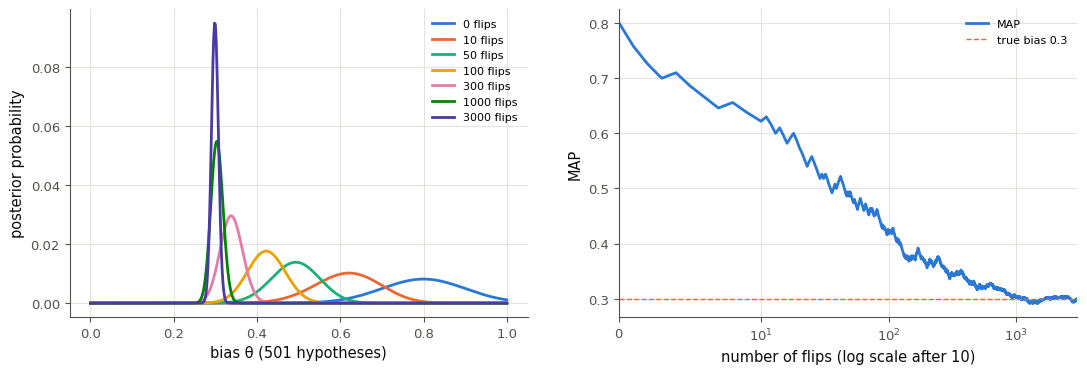

In [38]:
if any(answer is ... or answer is None for answer in [prediction_4_21a, prediction_4_21b, prediction_4_21c]):
    print("⏳ Ex 4.21 : écris d'abord tes trois prédictions, puis relance cette cellule.")
else:
    with wb.attempt("4.21"):
        history_21 = np.asarray(mylearn.bayes.update_discrete(PRIOR_21, TABLE_21, FLIPS_21, return_history=True))
        maps_21 = GRID_21[history_21.argmax(axis=1)]           # the MAP after 0, 1, ..., 3000 flips
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        for n in (0, 10, 50, 100, 300, 1000, 3000):
            axes[0].plot(GRID_21, history_21[n], label=f"{n} flips")
        axes[0].set_xlabel("bias θ (501 hypotheses)")
        axes[0].set_ylabel("posterior probability")
        axes[0].legend(fontsize=8)
        axes[1].plot(np.arange(len(maps_21)), maps_21, color="C0", label="MAP")
        axes[1].axhline(0.3, color="C1", ls="--", lw=1, label="true bias 0.3")
        axes[1].set_xscale("symlog", linthresh=10)
        axes[1].set_xlim(0, len(maps_21) - 1)
        axes[1].set_xlabel("number of flips (log scale after 10)")
        axes[1].set_ylabel("MAP")
        axes[1].legend(fontsize=8)
        plt.show()

Avec `history_21` (une ligne par nombre de lancers, de 0 à 3 000) et `maps_21` (le MAP après chaque nombre de lancers), calculés par l'expérience :
d) `map_100_21` : le MAP après 100 lancers (3 décimales) ;
e) `stays_21` : le plus petit nombre de lancers $n$ tel que, pour tous les nombres de lancers de $n$ à 3 000, le MAP est à moins de 0,015 de 0,3 (`np.abs(maps_21 - 0.3) < 0.015`).

In [39]:
map_100_21 = float(maps_21[100])
far_21 = np.abs(maps_21 - 0.3) >= 0.015              # too far from 0.3
stays_21 = int(np.flatnonzero(far_21).max()) + 1     # one more than the last one too far
print(map_100_21, stays_21, FLIPS_21[:100].mean())

0.422 815 0.33


In [40]:
wb.record("4.21d", map_100_21, decimals=3, mistakes={"c'est la proportion de faces des 100 premiers lancers, le MAP d'un prior UNIFORME : ici, le prior tire le MAP vers 0,8": float(FLIPS_21[:100].mean()),
                                                     "c'est le MAP après 99 lancers : la ligne 0 de maps_21 est le prior, la ligne k suit k lancers": float(maps_21[99]),
                                                     "c'est le MAP après 101 lancers : la ligne k de maps_21 suit exactement k lancers": float(maps_21[101])})
wb.record("4.21e", stays_21, mistakes={"c'est le DERNIER nombre de lancers où le MAP est encore trop loin : on demande le premier à partir duquel il reste proche": stays_21 - 1,
                                        "c'est la PREMIÈRE fois que le MAP s'approche à moins de 0,015 : il s'en éloigne encore ensuite": int(np.argmax(np.abs(maps_21 - 0.3) < 0.015))})

WB_ANSWER {"decimals": 3, "hash": "c1a80a2f4a297488c1319822fa245caed6c9b14e50d511b1d04863a5d6aa1da1", "hash_coarse": "94bb217e9042754213fad6468f982876a1672c1e7825fc1418753a9197edc9c2", "id": "4.21d", "kind": "float", "magnitude": -1, "mistakes": {"6fc9dafc60510adb7e2f96a4edc93382a8205daf859761dc7a85d5687d2e17f8": "c'est le MAP après 101 lancers : la ligne k de maps_21 suit exactement k lancers", "9c96f0b11fad34a1085a7c58b2ec32ad460f5abbf5ded57eacea84ef62528d90": "c'est la proportion de faces des 100 premiers lancers, le MAP d'un prior UNIFORME : ici, le prior tire le MAP vers 0,8", "ac3496e17b0697716408c8aa8c31cbacb52eb81fdbf742c7ef2dc61170d00809": "c'est le MAP après 99 lancers : la ligne 0 de maps_21 est le prior, la ligne k suit k lancers"}, "sign": 1}
📝 Ex 4.21d : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"hash": "30959d63371e09ff84c3925f0277c9d25bfecfcfe0bb4672128494147dcac014", "id": "4.21e", "kind": "int", "magnitude": 2, "mistakes": {"4e5716804585e02deee4547b117831

💡 Après 100 lancers (33 faces), le MAP vaut 0,42 : déjà plus près de 0,3 que de 0,8, mais encore nettement tiré vers la bosse du prior. Il ne reste à moins de 0,015 de 0,3 qu'à partir d'environ 800 lancers : il faut que les données dominent un prior qui donnait $3 \times 10^{-8}$ à l'hypothèse 0,3. Le prior ne disparaît jamais tout à fait : après 3 000 lancers, le posterior reste décalé d'environ un pas de la grille par rapport à celui d'un prior uniforme. Un prior trompeur coûte des données ; un prior **nul** coûterait tout (∂ 4.7).

### Ex 4.22 — Le posterior continu : vérifier avec scipy.stats.beta 📦 ★★ ⏱️ 20 min
**Objectif :** reconnaître la loi Beta dans le posterior d'une pièce, et la résumer avec `scipy.stats`.  
**Prérequis :** Ex 4.21 · fiche, au-delà du livre (2) (🧮 loi Beta) · ch. 2 (densité) · **Fil rouge :** synthétique · **Parcours :** M, C

Une pièce ancienne, lancée 20 fois, a donné 13 faces. Avec un prior **uniforme** sur $[0, 1]$, son posterior est une loi Beta (fiche, au-delà du livre (2)). Avec `scipy.stats.beta` :
a) `ab_22` : les deux paramètres $[a, b]$ de ce posterior (une liste de deux entiers) ;
b) `mean_22` : la moyenne du posterior (3 décimales) ;
c) `p_above_half_22` : $P(\theta > 0{,}5 \mid \text{données})$ (3 décimales) ;
d) `interval_22` : l'intervalle de crédibilité à 95 % à queues égales, `[basse, haute]` (3 décimales ; une méthode de la loi le donne directement).

La vérification contrôle ensuite, avec ta fonction `update_discrete` et un prior uniforme sur 1 001 points (`np.linspace(0, 1, 1001)`), que le posterior sur la grille est exactement la densité Beta normalisée sur la grille. Dans tes notes : pourquoi la moyenne n'est-elle pas égale à $\frac{13}{20}$ ?

In [41]:
HEADS_22, TAILS_22 = 13, 7
GRID_22 = np.linspace(0, 1, 1001)

In [42]:
posterior_22 = stats.beta(HEADS_22 + 1, TAILS_22 + 1)
ab_22 = [HEADS_22 + 1, TAILS_22 + 1]
mean_22 = float(posterior_22.mean())
p_above_half_22 = float(posterior_22.sf(0.5))
interval_22 = [float(v) for v in posterior_22.interval(0.95)]
print(ab_22, mean_22, p_above_half_22, interval_22, "mode:", HEADS_22 / (HEADS_22 + TAILS_22))

[14, 8] 0.6363636363636364 0.9053764343261719 [0.4303245170958757, 0.8189283744598268] mode: 0.65


In [43]:
wrong_22 = stats.beta(HEADS_22, TAILS_22)
wb.record("4.22a", ab_22, mistakes={"tu as oublié le prior uniforme, Beta(1, 1) : chaque paramètre gagne 1": [HEADS_22, TAILS_22],
                                     "a correspond aux FACES et b aux piles": [TAILS_22 + 1, HEADS_22 + 1]})
assert np.isclose(HEADS_22 / (HEADS_22 + TAILS_22), wrong_22.mean())    # the mode h / n is also the mean of Beta(h, t)
wb.record("4.22b", mean_22, decimals=3, mistakes={"c'est h / n, la proportion observée (le mode du posterior, ou la moyenne de Beta(h, t) sans le prior uniforme) : la moyenne d'une loi Beta n'est pas son mode": HEADS_22 / (HEADS_22 + TAILS_22)})
wb.record("4.22c", p_above_half_22, decimals=3, mistakes={"c'est P(θ < 0,5) : cdf donne la probabilité à GAUCHE (utilise sf, ou 1 - cdf)": float(posterior_22.cdf(0.5)),
                                                          "c'est la densité en 0,5, pas une probabilité : il faut une aire, cdf ou sf": float(posterior_22.pdf(0.5))})
wb.record("4.22d", interval_22, decimals=3, mistakes={"c'est l'intervalle de Beta(h, t), sans le prior uniforme": [float(v) for v in wrong_22.interval(0.95)],
                                                       "c'est un intervalle à 90 % : on demande 95 %": [float(v) for v in posterior_22.interval(0.90)],
                                                       "l'intervalle s'écrit [borne basse, borne haute]": interval_22[::-1]})

WB_ANSWER {"decimals": 0, "element_hashes": ["4c03f065a86e080d9e2b0635ee6732e290b1f01d8744c8aed03f31ba2eb47a97", "94ce7ef98a645c1bc2c9b8fa13a44de9ea5b0b17902b163649dea74604d0fae7"], "hash": "25806b408ab72d2f036f9cccbe61b9da67a510bbcd82b31819dec5db70d14563", "id": "4.22a", "integer": true, "kind": "array", "mistakes": {"16618f25dca4c7974fc0c3e0c3ed878f673d253cb210c09fc2d7e3126527a79a": "a correspond aux FACES et b aux piles", "33c3d2d1f1cc2ee9f59ef85ef3b8a3a6976e0ecfb6657b8e32544e6e7d433d00": "tu as oublié le prior uniforme, Beta(1, 1) : chaque paramètre gagne 1"}, "shape": [2]}
📝 Ex 4.22a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "463538153be54e7c6466698f9c66302dec311c5722ee66fd3d5caf5b996c193e", "hash_coarse": "d1eaa1bfedf6e5c8947217c851907a3f96471b4aef8a387e3ad87762fb902638", "id": "4.22b", "kind": "float", "magnitude": -1, "mistakes": {"f4051b36a0efacc1aba57afb18c403cc71b9f15d08074c257f685acd2b428fbf": "c'est h / n, la proportion observée (le mo

💡 Le posterior de 13 faces sur 20 avec un prior uniforme est $\mathrm{Beta}(14, 8)$. Sa moyenne, $\frac{14}{22} \approx 0{,}636$, est un peu tirée vers 0,5 par rapport au mode $\frac{13}{20} = 0{,}65$ : le prior uniforme compte comme une face et une pile « fictives » (règle de succession de Laplace). $P(\theta > 0{,}5) \approx 0{,}905$ : on est assez sûr que la pièce favorise face, pas certain. L'intervalle à 95 % va d'environ 0,43 à 0,82 : 20 lancers laissent beaucoup d'incertitude. La grille et la loi continue coïncident aux erreurs d'arrondi près : la loi Beta est la limite continue des figures du livre.

### Ex 4.23 — Refactoriser : du copier-coller à une fonction testée 🛠️ ★★ ⏱️ 20 min
**Objectif :** remplacer un code copié-collé par une fonction documentée, et la protéger par des tests qui attrapent les erreurs classiques.  
**Prérequis :** Ex 4.15 · 0A.61, 0A.62 (docstring, pytest) · ch. 2 (2.31) · **Fil rouge :** Penguins · **Parcours :** R, C

Un collègue calcule $P(\text{espèce} \mid \text{île})$ pour chaque île en recopiant trois fois le même bloc (cellule ci-dessous). C'est ce qu'on appelle du **copier-coller** : chaque copie peut diverger, et c'est arrivé.

a) `buggy_island_23` : lis les trois blocs : lequel est faux ? (le nom de l'île, une chaîne). Dans tes notes : quelle erreur, et quel contrôle simple, fait sur les résultats affichés, l'aurait révélée sans relire le code ?

**Refactoriser**, c'est réécrire du code sans changer ce qu'il fait (sauf le bug !), pour qu'il soit plus simple et plus sûr. Écris `species_given(df, column, value)`, qui renvoie $P(\text{espèce} \mid \text{df[column]} = \text{value})$ : une Series de probabilités, indexée par **toutes** les espèces du DataFrame dans l'ordre alphabétique, avec 0 pour une espèce absente du groupe. Donne-lui une docstring au format NumPy avec au moins les sections `Parameters`, `Returns` et `Examples` (0A.61).

Puis écris au moins **trois** tests pytest qui appellent `species_given`, sur un **petit DataFrame écrit à la main dans chaque test** (un test unitaire ne dépend pas d'un gros fichier de données), et range-les dans la liste `my_tests_23`. Par exemple : les probabilités somment à 1 ; une espèce absente du groupe a une probabilité de 0 ; un cas calculé à la main. Comme en 2.31, la vérification lance vraiment pytest : tes tests doivent **passer** sur une version juste et **échouer** sur chacune des trois versions buggées de la cellule suivante (lis-les). Tes tests peuvent utiliser `species_given`, `pd`, `np`, `math` et `pytest`.

In [44]:
# The colleague's analysis: P(species | island), one block per island (copy-pasted three times)
biscoe = penguins[penguins["island"] == "Biscoe"]
p_species_biscoe = biscoe["species"].value_counts() / len(biscoe)

dream = penguins[penguins["island"] == "Dream"]
p_species_dream = dream["species"].value_counts() / len(dream)

torgersen = penguins[penguins["island"] == "Torgersen"]
p_species_torgersen = torgersen["species"].value_counts() / len(biscoe)

print(p_species_biscoe.round(3), p_species_dream.round(3), p_species_torgersen.round(3), sep="\n\n")


def species_given_ok(df, column, value):
    """P(species | df[column] == value): a correct version, to test your tests."""
    chosen = df.loc[df[column] == value, "species"]
    return chosen.value_counts(normalize=True).reindex(sorted(df["species"].unique()), fill_value=0.0)


def species_given_bug_1(df, column, value):
    """Bug 1: divides by the size of the whole table instead of the size of the group."""
    chosen = df.loc[df[column] == value, "species"]
    return (chosen.value_counts() / len(df)).reindex(sorted(df["species"].unique()), fill_value=0.0)


def species_given_bug_2(df, column, value):
    """Bug 2: forgets the species that are absent from the group."""
    chosen = df.loc[df[column] == value, "species"]
    return chosen.value_counts(normalize=True).sort_index()


def species_given_bug_3(df, column, value):
    """Bug 3: reverses the condition, P(value | species) instead of P(species | value)."""
    table = pd.crosstab(df["species"], df[column], normalize="index")
    return table[value].reindex(sorted(df["species"].unique()), fill_value=0.0)

species
Gentoo    0.738
Adelie    0.262
Name: count, dtype: float64

species
Chinstrap    0.548
Adelie       0.452
Name: count, dtype: float64

species
Adelie    0.31
Name: count, dtype: float64


In [45]:
buggy_island_23 = "Torgersen"


def species_given(df, column, value):
    """Probability of each species among the rows where ``df[column] == value``.

    Parameters
    ----------
    df : pandas.DataFrame
        One row per animal, with a ``"species"`` column and the column ``column``.
    column : str
        The column that defines the group (for example ``"island"``).
    value : object
        The value of ``column`` that selects the group (for example ``"Dream"``).

    Returns
    -------
    pandas.Series
        P(species | df[column] == value), indexed by every species of ``df`` in
        alphabetical order (0 for a species absent from the group); it sums to 1.

    Examples
    --------
    >>> df = pd.DataFrame({"species": ["A", "A", "B", "C"], "island": ["x", "x", "x", "y"]})
    >>> species_given(df, "island", "x").round(3).tolist()
    [0.667, 0.333, 0.0]
    """
    chosen = df.loc[df[column] == value, "species"]
    return chosen.value_counts(normalize=True).reindex(sorted(df["species"].unique()), fill_value=0.0)


def test_probabilities_sum_to_one():
    df = pd.DataFrame({"species": ["A", "B", "B", "C", "A"], "island": ["x", "x", "y", "y", "y"]})
    for island in ["x", "y"]:
        assert species_given(df, "island", island).sum() == pytest.approx(1)


def test_absent_species_has_probability_zero():
    df = pd.DataFrame({"species": ["A", "A", "B"], "island": ["x", "x", "y"]})
    result = species_given(df, "island", "x")
    assert list(result.index) == ["A", "B"]
    assert result["B"] == 0


def test_hand_computed_case():
    df = pd.DataFrame({"species": ["A", "A", "A", "B", "B", "C"], "island": ["x", "x", "y", "x", "y", "y"]})
    result = species_given(df, "island", "x")
    assert result.tolist() == pytest.approx([2 / 3, 1 / 3, 0])


my_tests_23 = [test_probabilities_sum_to_one, test_absent_species_has_probability_zero, test_hand_computed_case]
print(species_given(penguins, "island", "Torgersen"))
with wb.attempt("4.23"):
    result_23 = species_given(penguins, "island", "Dream")
    expected_23 = pd.crosstab(penguins["species"], penguins["island"], normalize="columns")["Dream"].reindex(SPECIES)
    verdict("4.23", isinstance(result_23, pd.Series) and list(result_23.index) == SPECIES
            and np.allclose(result_23.to_numpy(dtype=float), expected_23.to_numpy()),
            "species_given(penguins, \"island\", \"Dream\") est juste (une Series indexée par les trois espèces).",
            "species_given(penguins, \"island\", \"Dream\") doit renvoyer une Series indexée par Adelie, Chinstrap, "
            "Gentoo, égale à la colonne Dream de pd.crosstab(..., normalize=\"columns\").")
    doc_23 = inspect.getdoc(species_given) or ""
    verdict("4.23", all(section in doc_23 for section in ("Parameters", "Returns", "Examples")),
            "la docstring a ses sections Parameters, Returns et Examples.",
            "la docstring doit avoir au moins les sections Parameters, Returns et Examples (format NumPy, 0A.61).")
if not filled(my_tests_23):
    print("⏳ Ex 4.23 : tests pas encore écrits.")
else:
    good_23 = wb.run_pytest(my_tests_23, subject=species_given_ok, name="species_given", preamble="import pandas as pd")
    verdict("4.23", good_23.ok and good_23.passed >= 3, f"tes tests passent sur une version juste ({good_23.passed} cas).",
            "tes tests doivent tous passer sur une version juste, et être au moins 3 (voir le détail au-dessus).")
    if good_23.ok:
        for bug in [species_given_bug_1, species_given_bug_2, species_given_bug_3]:
            result = wb.run_pytest(my_tests_23, subject=bug, name="species_given", preamble="import pandas as pd", quiet=True)
            verdict("4.23", result.failed + result.errors > 0, f"{bug.__name__} est attrapé ({result.failed} test(s) en échec).",
                    f"tes tests passent sur {bug.__name__}, qui est faux : ajoute un test qui le fait échouer.")

species
Adelie       1.0
Chinstrap    0.0
Gentoo       0.0
Name: proportion, dtype: float64
✅ Ex 4.23 : species_given(penguins, "island", "Dream") est juste (une Series indexée par les trois espèces).
✅ Ex 4.23 : la docstring a ses sections Parameters, Returns et Examples.


pytest : 3 passed in 0.46s
✅ Ex 4.23 : tes tests passent sur une version juste (3 cas).


✅ Ex 4.23 : species_given_bug_1 est attrapé (2 test(s) en échec).


✅ Ex 4.23 : species_given_bug_2 est attrapé (2 test(s) en échec).


✅ Ex 4.23 : species_given_bug_3 est attrapé (2 test(s) en échec).


In [46]:
wb.record("4.23a", buggy_island_23, mistakes={"ce bloc-là est juste : compare, dans chaque bloc, le groupe filtré et le nombre par lequel on divise": "Dream"})

WB_ANSWER {"hash": "023a6d5ea3aa9f10ffd558ac5ec965642be32ac7bb530624edd19e57d8c1f0aa", "id": "4.23a", "kind": "str", "mistakes": {"91670fc1c22771956af6934b9c5d151a09265c66afadb3ec5ceb862b0653d3bb": "ce bloc-là est juste : compare, dans chaque bloc, le groupe filtré et le nombre par lequel on divise"}}
📝 Ex 4.23a : réponse enregistrée (str).


💡 Dans le bloc Torgersen, la division se fait par `len(biscoe)` au lieu de `len(torgersen)` : les « probabilités » de Torgersen somment à 0,31 au lieu de 1. Rien ne plante, chaque nombre pris seul a l'air plausible, et c'est le danger du copier-coller : la troisième copie a gardé un morceau de la première. Un contrôle d'une ligne l'aurait révélée : des probabilités conditionnelles doivent sommer à 1. Une seule fonction, testée, supprime le risque : le calcul n'est écrit qu'une fois. Les trois tests attrapent chacun un bug : la somme à 1 attrape le bug 1, l'espèce absente le bug 2, le cas calculé à la main le bug 3 (la condition inversée).

## Partie D · 500 hypothèses en log, intervalles de crédibilité, et un défi

Fiche, « au-delà du livre » (1) à (3). Tu écris le calcul du posterior d'un biais en log-probabilités, puis l'intervalle de crédibilité, que tu compares à l'intervalle bootstrap du ch. 2 ; enfin, tu identifies vingt pièces avec le moins de lancers possible.

### Ex 4.24 — coin_bias_posterior : 500 hypothèses en log-probabilités 🔨 ★★★ ⏱️ 35 min
**Objectif :** calculer le posterior du biais d'une pièce sur une grille, en log-probabilités, sans underflow.  
**Prérequis :** Ex 4.16, Ex 4.18 · fiche, au-delà du livre (1) et (2) · **Fil rouge :** synthétique · **mylearn :** `bayes.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/bayes.py`, mêmes règles qu'en 4.14 (NumPy permis, SciPy non). Enregistre, puis relance la cellule de vérification.

Écris `coin_bias_posterior(flips, grid, prior=None)` (lis sa docstring) :
- compte les faces $h$ et les piles $t$ (les lancers ne valent que 0 ou 1, ou `False` et `True` comme ceux de `rng.random(n) < p` ; toute autre valeur lève une `ValueError`) ; les valeurs de la grille sont des biais entre 0 et 1 ; sans prior, prends le prior uniforme sur la grille ;
- calcule en logarithmes $\log P(\theta) + h \log\theta + t \log(1 - \theta)$, puis retranche le maximum, prends l'exponentielle et normalise (4.18) ;
- attention aux extrémités : avec $\theta = 0$, $\log\theta = -\infty$. Si $h = 0$, le terme vaut $\theta^0 = 1$ et ne doit pas donner `nan` ($0 \times (-\infty)$) : n'ajoute $h\log\theta$ que si $h > 0$ (de même pour $t$). `np.errstate(divide="ignore")` fait taire l'avertissement de $\log 0$ ;
- si toutes les hypothèses reçoivent la probabilité 0 (par exemple, une face et une pile avec la grille $\{0, 1\}$), lève une `ValueError`.

Vérifications : 20 000 lancers d'une pièce, sur une grille de 501 biais (`flips_24`, `GRID_24`). La cellule de vérification appelle ta fonction :
a) le MAP (la valeur de la grille de plus grand posterior) ;
b) l'écart-type du posterior, $\sqrt{\sum_\theta (\theta - m)^2\,P(\theta \mid \text{données})}$, où $m$ est la moyenne du posterior ;
puis deux contrôles (l'accord avec `update_discrete` sur 25 lancers, la durée des deux calculs sur 20 000 lancers) et les tests de `coin_bias_posterior`.

Dans tes notes : compare b) à l'erreur typique fréquentiste $\sqrt{\hat\theta(1 - \hat\theta)/n}$ du ch. 2. Pourquoi sont-elles si proches ?

In [47]:
GRID_24 = np.linspace(0, 1, 501)
flips_24 = wb.synth.coin_flips(20_000, 0.37, seed=24)
print(f"{flips_24.sum()} heads out of {len(flips_24)} flips")

7396 heads out of 20000 flips


In [48]:
post_24 = mylearn.bayes.coin_bias_posterior(flips_24, GRID_24)
map_24 = float(GRID_24[np.argmax(post_24)])
mean_24 = float(np.sum(GRID_24 * post_24))
sd_24 = float(np.sqrt(np.sum((GRID_24 - mean_24) ** 2 * post_24)))
share_24 = flips_24.mean()
print(map_24, sd_24, "frequentist typical error:", np.sqrt(share_24 * (1 - share_24) / len(flips_24)))
with wb.timer("update_discrete, 20 000 flips"):
    mylearn.bayes.update_discrete(np.full(501, 1 / 501), np.column_stack([1 - GRID_24, GRID_24]), flips_24)
with wb.timer("coin_bias_posterior, 20 000 flips"):
    mylearn.bayes.coin_bias_posterior(flips_24, GRID_24)
run_bayes_tests("test_coin_bias_posterior_", impl="ref")

0.37 0.0034133297338506735 frequentist typical error: 0.0034135608973621667


⏱️ update_discrete, 20 000 flips : 0.90 s
⏱️ coin_bias_posterior, 20 000 flips : 0.00 s


pytest: 25 passed, 74 deselected in 0.64s


In [49]:
wb.record("4.24a", map_24, decimals=4)
wb.record("4.24b", sd_24, decimals=4, mistakes={"c'est la variance : l'écart-type est sa racine": sd_24 ** 2})

WB_ANSWER {"decimals": 4, "hash": "d1ceb4aa79fd1a5c45082219703c3a242b6ed96d9efe0cbef808a8c3e829d380", "hash_coarse": "50237031132a222e4e143166bfe88846b43537d7e4fc09d0df105150c7e4b71b", "id": "4.24a", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 4.24a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "d2e861792f72e835bcde8717a34a6fed887be97d7187c01f3ec24fdb9c0e5806", "hash_coarse": "72d2650bea74fd1fd6af1d87be77e06e4e83a5c6b153d3015c3e00cd93f3851a", "id": "4.24b", "kind": "float", "magnitude": -3, "mistakes": {"7521ba7686d938786ce92b1b2ea72516cdba9ed00868cecbaf4e3281a78c09f6": "c'est la variance : l'écart-type est sa racine"}, "sign": 1}
📝 Ex 4.24b : réponse enregistrée (float, 4 décimale(s)).


💡 Après 20 000 lancers, le posterior est très étroit : son écart-type (environ 0,0034) est presque exactement l'erreur typique fréquentiste $\sqrt{\hat\theta(1 - \hat\theta)/n}$. Avec beaucoup de données et un prior plat, les deux écoles donnent les mêmes nombres (fiche §4.2, 🕰️). Le calcul en un seul passage (compter, puis une formule) est des centaines de fois plus rapide que la boucle, qui refait la règle de Bayes 20 000 fois : la boucle sert quand les observations arrivent une à une.

### Ex 4.25 — Intervalle de crédibilité contre intervalle bootstrap 🔨 ★★★ ⏱️ 35 min
**Objectif :** calculer un intervalle de crédibilité sur une grille et le comparer à l'intervalle bootstrap du ch. 2, surtout quand les données sont rares.  
**Prérequis :** Ex 4.24, Ex 2.22 (`bootstrap_ci`) · fiche, au-delà du livre (3) · **Fil rouge :** synthétique · **mylearn :** `bayes.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/bayes.py`, mêmes règles qu'en 4.14 (NumPy permis, SciPy non). Enregistre, puis relance la cellule de vérification.

Écris `credible_interval(grid, posterior, mass=0.95)` (lis sa docstring) : cumule le posterior (`np.cumsum`) ; la borne basse est la **première** valeur de la grille dont la probabilité cumulée **atteint** $\frac{1 - \text{mass}}{2}$ (elle est supérieure ou égale), la borne haute la première qui atteint $\frac{1 + \text{mass}}{2}$. Contrôle les entrées (grille strictement croissante, posterior qui est une distribution, `mass` strictement entre 0 et 1) et renvoie un tuple de deux `float` Python.

Vérifications, avec un prior uniforme sur la grille `GRID_25` et ta fonction `coin_bias_posterior` de 4.24. La cellule de vérification appelle tes fonctions :
a) l'intervalle de crédibilité à 95 % des 50 lancers `flips_25` ;
b) l'intervalle de confiance bootstrap des mêmes lancers, avec `mylearn.stats.bootstrap_ci(flips_25, rng=np.random.default_rng(25))` (ta fonction du ch. 2, ou la référence si tu ne l'as pas écrite) ;
c) l'intervalle de crédibilité à 95 % de dix lancers qui ont tous donné pile ;
puis les tests de `credible_interval`.

Enfin, la cellule `coverage_25` répète l'expérience sur 200 petits échantillons (10 lancers d'une pièce de biais 0,1) et compte combien de fois chaque intervalle contient le vrai biais. Dans tes notes : que vaut l'intervalle bootstrap de c) ? Pourquoi ? Quelle méthode tient le mieux sa promesse des 95 % sur les petits échantillons, et pourquoi ?

In [50]:
GRID_25 = np.linspace(0, 1, 1001)
flips_25 = wb.synth.coin_flips(50, 0.3, seed=25)
TEN_TAILS_25 = np.zeros(10, dtype=int)
print(f"{flips_25.sum()} heads out of {len(flips_25)} flips")


def coverage_25(theta=0.1, n=10, repetitions=200, seed=250):
    """Share of the intervals that contain theta: (credible interval, bootstrap interval), on small samples."""
    rng = np.random.default_rng(seed)
    grid = np.linspace(0, 1, 1001)
    inside_credible = inside_bootstrap = zero_heads = 0
    for _ in range(repetitions):
        flips = (rng.random(n) < theta).astype(int)
        low, high = mylearn.bayes.credible_interval(grid, mylearn.bayes.coin_bias_posterior(flips, grid))
        b_low, b_high = mylearn.stats.bootstrap_ci(flips, rng=rng)
        inside_credible += low <= theta <= high
        inside_bootstrap += b_low <= theta <= b_high
        zero_heads += flips.sum() == 0
    return inside_credible / repetitions, inside_bootstrap / repetitions, zero_heads

21 heads out of 50 flips


In [51]:
posterior_25 = mylearn.bayes.coin_bias_posterior(flips_25, GRID_25)
credible_25 = mylearn.bayes.credible_interval(GRID_25, posterior_25)
bootstrap_25 = mylearn.stats.bootstrap_ci(flips_25, rng=np.random.default_rng(25))
tails_25 = mylearn.bayes.credible_interval(GRID_25, mylearn.bayes.coin_bias_posterior(TEN_TAILS_25, GRID_25))
print(credible_25, bootstrap_25, tails_25, mylearn.stats.bootstrap_ci(TEN_TAILS_25, rng=np.random.default_rng(25)))
run_bayes_tests("test_credible_interval_", impl="ref")
credible_share_25, bootstrap_share_25, zero_25 = coverage_25()
print(f"coverage on 200 samples of 10 flips (bias 0.1): credible {credible_share_25:.2f}, "
      f"bootstrap {bootstrap_share_25:.2f} ({zero_25} samples without any heads)")

(0.293, 0.558) (0.28, 0.56) (0.002, 0.28500000000000003) (0.0, 0.0)


pytest: 20 passed, 79 deselected in 0.77s


coverage on 200 samples of 10 flips (bias 0.1): credible 0.91, bootstrap 0.63 (73 samples without any heads)


In [52]:
wb.record("4.25a", list(credible_25), decimals=4, mistakes={"c'est un intervalle à 90 % : on demande 95 %": list(mylearn.bayes.credible_interval(GRID_25, posterior_25, mass=0.90))})
wb.record("4.25b", list(bootstrap_25), decimals=4)
wb.record("4.25c", list(tails_25), decimals=4)

WB_ANSWER {"decimals": 4, "element_coarse": [["4c1215976f9901dfa8b2b2d89f1749f20c980746c5c6f1483bb7e9a84d392a57"], ["01e1c9d204af2898f1784931dbb2cbce1c5873ae87075b654188b1f9db3ea74c"]], "element_hashes": ["531d699b37f364f3a6c6093910c9496bcbc94649adc086ba46bdb44d19b7739a", "7716b6416d9c0a99f8e6a597d62935f5ec58f8180659948e3feb54f1139a5f6b"], "hash": "4219ac49c2a0fde8f86f136727448b9f28eaca2f2762f64b1460ef96338f9d4d", "id": "4.25a", "kind": "array", "mistakes": {"e06bf5ef3c8fd8a636d4620c562e8f15f5ea816c15d7cb0bfb35c9cca6b7c287": "c'est un intervalle à 90 % : on demande 95 %"}, "shape": [2]}
📝 Ex 4.25a : réponse enregistrée (array, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "element_coarse": [["3574efb1618c0b7119f58cd4365150b186d580ce094ecf9e60e67e643d999959"], ["1b0b40fab453eccec9b0597205166f9eaf711c1d2c0eb378a54b9828179bd798"]], "element_hashes": ["6f333aa40bbfc1a40584310e1d74546e135699cdc1244fda595eb3ae6941e4c8", "8d3ab7daf12007d7e4ab2772902a80b24ef43c782bdd729b155830d8582de19b"], "hash":

💡 Sur 50 lancers, les deux intervalles se ressemblent (environ 0,29 à 0,56 pour le premier, 0,28 à 0,56 pour le second) : avec assez de données, le bootstrap et un prior plat racontent la même histoire. Sur dix piles, tout change : le bootstrap ne rééchantillonne que des piles et répond (0 ; 0), « le biais vaut 0, sans aucun doute ». L'intervalle de crédibilité, lui, va de presque 0 à environ 0,285 : dix lancers ne suffisent pas à exclure un biais de 0,2. Sur 200 petits échantillons, l'intervalle de crédibilité contient le vrai biais bien plus souvent que l'intervalle bootstrap. Avec très peu de données, le bootstrap percentile promet plus qu'il ne tient ; un prior raisonnable, lui, garde une part de doute.

### Ex 4.26 — Le détective de pièces : vingt pièces, le moins de lancers possible 🏆 ★★★ ⏱️ 60 min
**Objectif :** identifier le biais de vingt pièces avec un budget de lancers serré, en dépensant les lancers là où l'on est le moins sûr.  
**Prérequis :** Ex 4.24, Ex 4.12 · fiche §4.6, §4.7 · **Fil rouge :** synthétique · **Parcours :** C

**Défi.** L'archéologue t'envoie un sac de vingt pièces. Le biais de chacune est l'une des cinq valeurs de `CANDIDATES_26` (0,2 ; 0,35 ; 0,5 ; 0,65 ; 0,8), mais tu ne sais pas laquelle. Tu peux lancer la pièce $i$ avec `bag.flip(i)`, qui renvoie 1 (face) ou 0 (pile). Chaque lancer compte : tu as droit à **2 400 lancers en tout** pour les vingt pièces (`BUDGET_26`), et tu dois identifier au moins **19 pièces sur 20**.

Écris `detective_26(bag)`, qui renvoie la liste des vingt biais que tu annonces (des valeurs de `CANDIDATES_26`). Commence par la stratégie de base : pour chaque pièce, partir du prior uniforme sur les cinq candidats, lancer et mettre à jour (`update_discrete`) jusqu'à ce que le plus grand posterior dépasse 0,99, puis annoncer le MAP. Sur ce sac, elle dépasse le budget : à toi de faire mieux. La vérification lance ta fonction sur le sac de la graine 434, puis sur 20 autres sacs : le défi est réussi si tu tiens l'objectif sur le sac 434 **et** sur au moins 15 des 20 autres (une bonne stratégie ne dépend pas d'un sac particulier).

Pistes : que coûte un seuil plus bas, en pièces mal identifiées ? Un plafond de lancers par pièce aide-t-il ? Toutes les pièces demandent-elles autant de lancers, et dans quel ordre vaut-il mieux les lancer ? N'ouvre pas `bag._biases` : ce serait tricher.

In [53]:
CANDIDATES_26 = np.array([0.2, 0.35, 0.5, 0.65, 0.8])    # the possible biases of the coins
BUDGET_26 = 2400                                          # flips allowed for the 20 coins together


class CoinBag:
    """Twenty coins whose biases are hidden (taken from CANDIDATES_26). Flip coin i with bag.flip(i)."""

    def __init__(self, seed):
        self._biases = np.random.default_rng(seed).choice(CANDIDATES_26, size=20)
        self._rngs = [np.random.default_rng([seed, i]) for i in range(20)]   # one stream per coin
        self.flips_used = 0

    def flip(self, i):
        """One flip of coin i: 1 (heads) or 0 (tails). Every call counts in the budget."""
        self.flips_used += 1
        return int(self._rngs[i].random() < self._biases[i])

    def score(self, answers):
        """Number of coins whose bias is right (used by the check: do not peek at self._biases)."""
        return int(np.sum(np.asarray(answers, dtype=float) == self._biases))

In [54]:
def detective_26(bag, threshold=0.99, warm_up=5):
    """The list of the 20 biases you announce (values of CANDIDATES_26), using bag.flip(i)."""
    table = np.column_stack([1 - CANDIDATES_26, CANDIDATES_26])        # columns: P(tails), P(heads)
    uniform = np.full(len(CANDIDATES_26), 1 / len(CANDIDATES_26))
    # a few flips of every coin first, then always the coin we are least sure about
    posteriors = [mylearn.bayes.update_discrete(uniform, table, [bag.flip(i) for _ in range(warm_up)])
                  for i in range(20)]
    sure = np.array([posterior.max() for posterior in posteriors])
    while bag.flips_used < BUDGET_26 and sure.min() <= threshold:
        i = int(np.argmin(sure))
        posteriors[i] = mylearn.bayes.update_discrete(posteriors[i], table, [bag.flip(i)])
        sure[i] = posteriors[i].max()
    return [float(CANDIDATES_26[np.argmax(posterior)]) for posterior in posteriors]


with wb.attempt("4.26"):
    bag_26 = CoinBag(434)
    answers_26 = detective_26(bag_26)
    score_26, used_26 = bag_26.score(answers_26), bag_26.flips_used
    others_26 = []
    for seed in range(1000, 1020):                       # 20 other bags: the strategy must not depend on one bag
        bag = CoinBag(seed)
        others_26.append((bag.score(detective_26(bag)), bag.flips_used))
    others_26 = np.array(others_26)
    succeeded_26 = int(np.sum((others_26[:, 0] >= 19) & (others_26[:, 1] <= BUDGET_26)))
    print(f"bag 434: {score_26} coins right out of 20, {used_26} flips (budget {BUDGET_26}); "
          f"20 other bags: {succeeded_26} successes, flips used from {others_26[:, 1].min()} to {others_26[:, 1].max()}")
    verdict("4.26", len(answers_26) == 20 and score_26 >= 19 and used_26 <= BUDGET_26 and succeeded_26 >= 15,
            f"défi réussi : {score_26} pièces sur 20 sur le sac 434, en {used_26} lancers, et l'objectif tenu sur "
            f"{succeeded_26} des 20 autres sacs.",
            f"sac 434 : {score_26} pièces sur 20 en {used_26} lancers ; objectif tenu sur {succeeded_26} des 20 autres "
            f"sacs. Il faut au moins 19 pièces sur 20 en {BUDGET_26} lancers au plus sur le sac 434, et l'objectif "
            f"tenu sur au moins 15 des 20 autres sacs.")

bag 434: 20 coins right out of 20, 2400 flips (budget 2400); 20 other bags: 20 successes, flips used from 2009 to 2400
✅ Ex 4.26 : défi réussi : 20 pièces sur 20 sur le sac 434, en 2400 lancers, et l'objectif tenu sur 20 des 20 autres sacs.


💡 La stratégie de base dépense ses lancers pièce après pièce : elle identifie les 20 pièces de ce sac, mais en 2 446 lancers, au-delà du budget. Baisser le seuil à 0,98 passe ici (20 sur 20 en 2 137 lancers), mais échoue sur environ un sac sur cinq ; s'arrêter simplement quand le budget est épuisé passe ce sac, mais pas assez d'autres. La solution ci-dessus répartit le budget : cinq lancers pour chaque pièce, puis toujours la pièce dont on est le moins sûr, jusqu'à ce que toutes dépassent 0,99 ou que le budget soit épuisé. Elle réussit sur ce sac, sur les 20 autres, et sur environ 95 % des 200 sacs de graines 5000 à 5199. Les pièces difficiles sont celles des candidats intérieurs (0,35, 0,5 et 0,65), qui ont un voisin de chaque côté : il leur faut souvent 120 à 140 lancers, contre 70 environ pour 0,2 et 0,8. C'est là que les lancers servent. C'est la logique des tests séquentiels et des tests A/B bayésiens : dépenser l'effort là où l'incertitude reste.

## ✅ Bilan

**Auto-évaluation** (note-toi de 0 à 3 dans `mon_travail/suivi/auto_evaluation.md`) :
1. Sais-tu écrire la règle de Bayes, nommer ses quatre termes et la retrouver à partir de la règle du produit ?
2. Sais-tu mettre à jour une distribution sur plusieurs hypothèses, observation après observation, sans underflow ?
3. Sais-tu expliquer la différence entre un intervalle de crédibilité et un intervalle de confiance, et quand ils diffèrent ?

**Pour aller plus loin** : la vidéo de 3Blue1Brown et le livre en ligne *Think Bayes*, cités dans la fiche ; l'article de VanderPlas (4.11). La suite : le ch. 5 (courbes et surfaces), puis le ch. 6, qui additionne lui aussi des log-probabilités (entropie, log loss) ; `mylearn.bayes` resservira au ch. 9 (régression « à la Bayes ») et au ch. 13 (Naive Bayes).